# Grapevine leaf morphospace: eigenleaves, LDA classification, and synthetic leaves

**Paper:** D. H. Chitwood, *A high resolution model of the grapevine leaf morphospace predicts synthetic leaves*, bioRxiv 2024, doi:[10.1101/2024.03.08.584086](https://doi.org/10.1101/2024.03.08.584086)
**Author code:** [DanChitwood/synthetic_leaves](https://github.com/DanChitwood/synthetic_leaves) @ commit `9b7447c2a985e3d3aa2cfcedcbc98b81857d904d` (MIT license) — `ampelography.ipynb`, ported to Colab.

**Scope / スコープ:** Partial demonstration — the morphospace + classification subsection. From the author's bundled leaf-trace dataset (`data.zip`, 1.1 MB): automatic landmark & pseudo-landmark detection, Procrustes/GPA alignment, PCA eigenleaves (PC1–PC9), linear discriminant analysis of **genotype** and **developmental stage** with confusion matrices, and 500 synthetic leaves sampled from the 9-D convex hull. Omitted: bootstrap validations, developmental polynomial modeling, prediction-shaded morphospace maps, original leaf images (Figshare record 10.6084/m9.figshare.25325980).

**部分的な再現です**：形態空間・識別の節のみ。ブートストラップ検証・発生の多項式モデリング・予測着色モルフォスペース等は省略しています。

**Author-code statement:** Nearly all scientific code below is copied verbatim from the author's MIT-licensed `ampelography.ipynb` (functions `angle_between` … `calc_gpa_mean`, landmark/pseudo-landmark detection, GPA, PCA, LDA, convex-hull sampling). Documented adaptations: Colab paths under `/content`; inline display instead of writing PNGs to `./images`; `cm.get_cmap('plasma',100)` → `matplotlib.colormaps['plasma']` and `np.math.factorial` → `math.factorial` (APIs removed in current matplotlib/numpy); a fixed RNG seed for synthetic-leaf sampling; guarded `.DS_Store` skip. The authors did not provide this Colab notebook itself; untested behavior is not guaranteed.
**著者コードの多くはMITライセンスの `ampelography.ipynb` からの逐語コピーです。**変更点（パス、インライン表示、非推奨API修正、乱数シード固定）は各セルに明記しています。

## Runtime: CPU only / ランタイム: CPU

This notebook uses only NumPy/SciPy/scikit-learn linear algebra on ~139 leaf shapes (≈1672 coordinates each). **No GPU is needed** — select *Runtime → Change runtime type → CPU*. End-to-end is well under 15 minutes on a standard CPU runtime; the only download is the 1.1 MB `data.zip`.

このノートブックはCPUのみで動作します（GPU不要）。ランタイム → ランタイムのタイプを変更 → CPU を選択してください。ダウンロードは data.zip (約1.1MB) のみ。*Run all*（すべてのセルを実行）で先頭から実行できます。

In [ ]:
import sys, platform
print('python', sys.version)
print('machine', platform.machine())
# CPU-only workload: no CUDA/GPU requirement. If a GPU runtime is attached it is simply unused.
# 科学計算はすべてCPU上のnumpy/scipy/scikit-learnで実行されます。


python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
machine x86_64


## Dependencies / 依存ライブラリ

The author's imports (numpy, pandas, scipy, scikit-learn, matplotlib, seaborn) are preinstalled on Colab — no `pip install` needed. Versions are printed for provenance.
必要なライブラリはColabにプリインストール済みのため、インストールは不要です。

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from scipy.optimize import curve_fit
from scipy.spatial import procrustes, ConvexHull, Delaunay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from scipy.stats import dirichlet
from numpy.linalg import det
from os import listdir
from os.path import isfile, join

import scipy, sklearn
for m in (np, pd, matplotlib, scipy, sklearn):
    print(m.__name__, m.__version__)
print('seaborn', sns.__version__)


numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0
scipy 1.16.3
sklearn 1.6.1
seaborn 0.13.2


## Input: author-bundled trace data / 入力データ

Download `data.zip` from the **pinned commit** and verify its git blob SHA-1 and byte count against the GitHub tree listing (`3cf8fa97…`, 1,131,399 bytes). Unzip under `/content`, skipping the macOS `__MACOSX` entries. Each leaf has three files: `<ID>_<name>_veins.txt` (vein trace polyline, pixels), `<ID>_<name>_blade.txt` (blade outline), `<ID>_<name>_info.csv` (metadata incl. the `px2_cm2` cm²-per-px² scale).
コミットを固定したURLから data.zip をダウンロードし、git blob SHA-1 とサイズを検証してから展開します。

In [ ]:
import urllib.request, hashlib, zipfile, os

COMMIT = '9b7447c2a985e3d3aa2cfcedcbc98b81857d904d'
BASE = f'https://raw.githubusercontent.com/DanChitwood/synthetic_leaves/{COMMIT}/'
EXPECTED_BLOB_SHA = '3cf8fa976322cee7dc4b3b825551a2c9c5f77d8a'
EXPECTED_BYTES = 1131399

urllib.request.urlretrieve(BASE + 'data.zip', '/content/data.zip')
raw = open('/content/data.zip', 'rb').read()
h = hashlib.sha1(); h.update(b'blob %d\0' % len(raw)); h.update(raw)
assert len(raw) == EXPECTED_BYTES, len(raw)
assert h.hexdigest() == EXPECTED_BLOB_SHA, h.hexdigest()
print('data.zip verified:', len(raw), 'bytes, git blob', h.hexdigest())

with zipfile.ZipFile('/content/data.zip') as z:
    members = [m for m in z.namelist()
               if m.startswith('data/') and not m.endswith('/') and '__MACOSX' not in m]
    z.extractall('/content', members=members)
files = os.listdir('/content/data')
leaves = {f.rsplit('_', 1)[0] for f in files}
print('files:', len(files), '| unique leaf identifiers:', len(leaves))


data.zip verified: 1131399 bytes, git blob 3cf8fa976322cee7dc4b3b825551a2c9c5f77d8a
files: 457 | unique leaf identifiers: 153


### Author functions: geometry helpers / 著者関数（幾何ヘルパー）

Verbatim from `ampelography.ipynb` cell 4 (MIT license): anti-clockwise angle between three points, 2-D rotation, arc-length-resampled interpolation, Euclidean distance.
`ampelography.ipynb` のセル4から逐語コピー。

In [ ]:
# define functions

def angle_between(p1, p2, p3):
    """
    define a function to find the angle between 3 points anti-clockwise in degrees, p2 being the vertex
    inputs: three angle points, as tuples
    output: angle in degrees
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    deg1 = (360 + math.degrees(math.atan2(x1 - x2, y1 - y2))) % 360
    deg2 = (360 + math.degrees(math.atan2(x3 - x2, y3 - y2))) % 360
    return deg2 - deg1 if deg1 <= deg2 else 360 - (deg1 - deg2)

def rotate_points(xvals, yvals, degrees):
    """"
    define a function to rotate 2D x and y coordinate points around the origin
    inputs: x and y vals (can take pandas dataframe columns) and the degrees (positive, anticlockwise) to rotate
    outputs: rotated and y vals
    """
    angle_to_move = 270 - degrees
    rads = np.deg2rad(angle_to_move)
    
    new_xvals = xvals*np.cos(rads)-yvals*np.sin(rads)
    new_yvals = xvals*np.sin(rads)+yvals*np.cos(rads)
    
    return new_xvals, new_yvals

def interpolation(x, y, number): 
    """
    define a function to return equally spaced, interpolated points for a given polyline
    inputs: arrays of x and y values for a polyline, number of points to interpolate
    ouputs: interpolated points along the polyline, inclusive of start and end points
    """
    distance = np.cumsum(np.sqrt( np.ediff1d(x, to_begin=0)**2 + np.ediff1d(y, to_begin=0)**2 ))
    distance = distance/distance[-1]

    fx, fy = interp1d( distance, x ), interp1d( distance, y )

    alpha = np.linspace(0, 1, number)
    x_regular, y_regular = fx(alpha), fy(alpha)
    
    return x_regular, y_regular

def euclid_dist(x1, y1, x2, y2):
    """
    define a function to return the euclidean distance between two points
    inputs: x and y values of the two points
    output: the eulidean distance
    """
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)


### Author functions: landmark / pseudo-landmark / GPA functions (continued)

Verbatim, remaining cell-4 functions: `detect_landmark` and `internal_landmarks` (25 vein tips → 40 internal landmarks), `interpolated_intervals` (num_land pseudo-landmarks per interval), `rotate_and_scale` (PCA-based rotation to tip-down orientation, pixel→cm scaling via `px2_cm2`), `PolyArea` (shoelace formula), and `calc_gpa_mean` (generalized Procrustes mean by iteration).
残りの著者関数（ランドマーク検出・擬似ランドマーク・スケール正規化・GPA平均）もそのままコピー。

In [ ]:
def detect_landmark(vein,tip_indices,start_ind,end_ind,ref_ind,use_forward=True,use_max=True):
    """
    define a function to find index of farthest/closest point from ref index point for a set of vein coordinates
    inputs: 2D array of vein points, rows are points columns x and y coordinate values,
    indices of tips, start index, end index, reference idex
    if use_forward=True, then should be used on the forward side of the leaf, otherwise the reverse
    if use_max=True, then finds furthest point from ref, otherwise closest
    ouputs: index of the farthest/closest point from reference
    dependencies: uses the funciton euclid_dist
    """
    ref_dist = [] # store distances to end index 
    dist_ind = [] # store indices for each distance
    if use_forward==True:
        for i in range(start_ind+1, end_ind):
            ref_dist.append(euclid_dist(vein[ref_ind,0],vein[ref_ind,1],vein[i,0],vein[i,1]))
            dist_ind.append(i)
    else:
        for i in range(end_ind+1, start_ind):
            ref_dist.append(euclid_dist(vein[ref_ind,0],vein[ref_ind,1],vein[i,0],vein[i,1]))
            dist_ind.append(i)
    if use_max==True:  
        max_dist_ind = ref_dist.index(max(ref_dist))
        pt_ind = dist_ind[max_dist_ind]
    else:
        min_dist_ind = ref_dist.index(min(ref_dist))
        pt_ind = dist_ind[min_dist_ind]
    return pt_ind
    
def internal_landmarks(vein,tip_indices):
    """
    define a function to return indices of internal vein landmarks given vein tip indices
    inputs: 2D array of vein points, rows are points columns x and y coordinate values,
    indices of tips
    ouputs: a list of indices of internal vein landmarks
    dependencies: detect_landmark
    """
    ### FORWARD SIDE OF LEAF
    
    ### PROXIMAL LOBE
    ### POINT B, 1
    ptB_ind = detect_landmark(vein,tip_indices,tip_indices[1],tip_indices[2],tip_indices[2],use_forward=True,use_max=True)
    ### POINT A, 2
    ptA_ind = detect_landmark(vein,tip_indices,tip_indices[0],tip_indices[1],ptB_ind,use_forward=True,use_max=False)
    ### POINT D, 3
    ptD_ind = detect_landmark(vein,tip_indices,tip_indices[2],tip_indices[3],tip_indices[3],use_forward=True,use_max=True)
    ### POINT C, 4
    ptC_ind = detect_landmark(vein,tip_indices,tip_indices[1],tip_indices[2],ptD_ind,use_forward=True,use_max=False)
    ### POINT F, 5
    ptF_ind = detect_landmark(vein,tip_indices,tip_indices[3],tip_indices[4],tip_indices[4],use_forward=True,use_max=True)
    ### POINT E, 6
    ptE_ind = detect_landmark(vein,tip_indices,tip_indices[2],tip_indices[3],ptF_ind,use_forward=True,use_max=False)
    ### POINT G, 7
    ptG_ind = detect_landmark(vein,tip_indices,tip_indices[4],tip_indices[5],tip_indices[5],use_forward=True,use_max=True)

    ### DISTAL LOBE
    ### POINT I, 8
    ptI_ind = detect_landmark(vein,tip_indices,tip_indices[5],tip_indices[6],tip_indices[6],use_forward=True,use_max=True)
    ### POINT H, 9
    ptH_ind = detect_landmark(vein,tip_indices,tip_indices[4],tip_indices[5],ptI_ind,use_forward=True,use_max=False)
    ### POINT K, 10
    ptK_ind = detect_landmark(vein,tip_indices,tip_indices[6],tip_indices[7],tip_indices[7],use_forward=True,use_max=True)
    ### POINT J, 11
    ptJ_ind = detect_landmark(vein,tip_indices,tip_indices[5],tip_indices[6],ptK_ind,use_forward=True,use_max=False)
    ### POINT M, 12
    ptM_ind = detect_landmark(vein,tip_indices,tip_indices[7],tip_indices[8],tip_indices[8],use_forward=True,use_max=True)
    ### POINT L, 13
    ptL_ind = detect_landmark(vein,tip_indices,tip_indices[6],tip_indices[7],ptM_ind,use_forward=True,use_max=False)
    ### POINT N, 14
    ptN_ind = detect_landmark(vein,tip_indices,tip_indices[8],tip_indices[9],tip_indices[9],use_forward=True,use_max=True)
    
    ### MIDVEIN
    ### POINT P, 15
    ptP_ind = detect_landmark(vein,tip_indices,tip_indices[9],tip_indices[10],tip_indices[10],use_forward=True,use_max=True)
    ### POINT O, 16
    ptO_ind = detect_landmark(vein,tip_indices,tip_indices[8],tip_indices[9],ptP_ind,use_forward=True,use_max=False)
    ### POINT R, 17
    ptR_ind = detect_landmark(vein,tip_indices,tip_indices[10],tip_indices[11],tip_indices[11],use_forward=True,use_max=True)
    ### POINT Q, 18
    ptQ_ind = detect_landmark(vein,tip_indices,tip_indices[9],tip_indices[10],ptR_ind,use_forward=True,use_max=False)
    ### POINT T, 19
    ptT_ind = detect_landmark(vein,tip_indices,tip_indices[11],tip_indices[12],tip_indices[12],use_forward=True,use_max=True)
    ### POINT S, 20
    ptS_ind = detect_landmark(vein,tip_indices,tip_indices[10],tip_indices[11],ptT_ind,use_forward=True,use_max=False)

    ### REVERSE SIDE OF LEAF
    
    ### PROXIMAL LOBE
    ### POINT zB
    ptzB_ind = detect_landmark(vein,tip_indices,tip_indices[-2],tip_indices[-3],tip_indices[-3],use_forward=False,use_max=True)
    ### POINT zA
    ptzA_ind = detect_landmark(vein,tip_indices,tip_indices[-1],tip_indices[-2],ptzB_ind,use_forward=False,use_max=False)
    ### POINT zD
    ptzD_ind = detect_landmark(vein,tip_indices,tip_indices[-3],tip_indices[-4],tip_indices[-4],use_forward=False,use_max=True)
    ### POINT zC
    ptzC_ind = detect_landmark(vein,tip_indices,tip_indices[-2],tip_indices[-3],ptzD_ind,use_forward=False,use_max=False)
    ### POINT zF
    ptzF_ind = detect_landmark(vein,tip_indices,tip_indices[-4],tip_indices[-5],tip_indices[-5],use_forward=False,use_max=True)
    ### POINT zE
    ptzE_ind = detect_landmark(vein,tip_indices,tip_indices[-3],tip_indices[-4],ptzF_ind,use_forward=False,use_max=False)
    ### POINT zG
    ptzG_ind = detect_landmark(vein,tip_indices,tip_indices[-5],tip_indices[-6],tip_indices[-6],use_forward=False,use_max=True)

    ### DISTAL LOBE
    ### POINT zI
    ptzI_ind = detect_landmark(vein,tip_indices,tip_indices[-6],tip_indices[-7],tip_indices[-7],use_forward=False,use_max=True)
    ### POINT zH
    ptzH_ind = detect_landmark(vein,tip_indices,tip_indices[-5],tip_indices[-6],ptzI_ind,use_forward=False,use_max=False)
    ### POINT zK
    ptzK_ind = detect_landmark(vein,tip_indices,tip_indices[-7],tip_indices[-8],tip_indices[-8],use_forward=False,use_max=True)
    ### POINT zJ
    ptzJ_ind = detect_landmark(vein,tip_indices,tip_indices[-6],tip_indices[-7],ptzK_ind,use_forward=False,use_max=False)
    ### POINT zM
    ptzM_ind = detect_landmark(vein,tip_indices,tip_indices[-8],tip_indices[-9],tip_indices[-9],use_forward=False,use_max=True)
    ### POINT zL
    ptzL_ind = detect_landmark(vein,tip_indices,tip_indices[-7],tip_indices[-8],ptzM_ind,use_forward=False,use_max=False)
    ### POINT zN
    ptzN_ind = detect_landmark(vein,tip_indices,tip_indices[-9],tip_indices[-10],tip_indices[-10],use_forward=False,use_max=True)

    ### MIDVEIN
    ### POINT zP
    ptzP_ind = detect_landmark(vein,tip_indices,tip_indices[-10],tip_indices[-11],tip_indices[-11],use_forward=False,use_max=True)
    ### POINT zO
    ptzO_ind = detect_landmark(vein,tip_indices,tip_indices[-9],tip_indices[-10],ptzP_ind,use_forward=False,use_max=False)
    ### POINT zR
    ptzR_ind = detect_landmark(vein,tip_indices,tip_indices[-11],tip_indices[-12],tip_indices[-12],use_forward=False,use_max=True)
    ### POINT zQ
    ptzQ_ind = detect_landmark(vein,tip_indices,tip_indices[-10],tip_indices[-11],ptzR_ind,use_forward=False,use_max=False)
    ### POINT zT
    ptzT_ind = detect_landmark(vein,tip_indices,tip_indices[-12],tip_indices[-13],tip_indices[-13],use_forward=False,use_max=True)
    ### POINT zS
    ptzS_ind = detect_landmark(vein,tip_indices,tip_indices[-11],tip_indices[-12],ptzT_ind,use_forward=False,use_max=False)
    
    landmark_indices = [ptA_ind,ptB_ind,ptC_ind,ptD_ind,ptE_ind,ptF_ind,ptG_ind,ptH_ind,ptI_ind,ptJ_ind,
             ptK_ind,ptL_ind,ptM_ind,ptN_ind,ptO_ind,ptP_ind,ptQ_ind,ptR_ind,ptS_ind,ptT_ind,
             ptzT_ind,ptzS_ind,ptzR_ind,ptzQ_ind,ptzP_ind,ptzO_ind,ptzN_ind,ptzM_ind,ptzL_ind,ptzK_ind,
             ptzJ_ind,ptzI_ind,ptzH_ind,ptzG_ind,ptzF_ind,ptzE_ind,ptzD_ind,ptzC_ind,ptzB_ind,ptzA_ind
            ]
    
    return landmark_indices

def interpolated_intervals(land_indices, new_xvals, new_yvals, num_land):
    
    """
    define a function to return interpolated points for each interval between landmarks of a trace file
    inputs: landmark indices, xvals and yvals of polyline at desired resolution,
    number of interpolated landmarks per interval
    outputs: lists of x and y values with specified number of interpolated points per interval
    dependencies: interpolation
    """
    
    inter_points_x = [] # list to store interpolated x vals
    inter_points_y = [] # list to store interpolated y vals

    for i in range(len(land_indices)-1): # for each index, minus 1, because we are analyzing intervals

        beg_ind = land_indices[i] # specify the beginning point, based on index
        end_ind = land_indices[i+1] # specify the end point, based on index

        interval_xvals = new_xvals[beg_ind:end_ind] # using indices above, find the interval of x vals
        interval_yvals = new_yvals[beg_ind:end_ind] # using indices above, find the interval of y vals

        curr_inter_xvals, curr_inter_yvals = interpolation(interval_xvals, interval_yvals, num_land) # interpolate the interval

        curr_inter_xvals = list(curr_inter_xvals) # convert interval x vals into a list
        curr_inter_yvals = list(curr_inter_yvals) # convert interval y vals into a list

        # to prevent duplicated pseudo-landmark points, because we are working with intervals:

        if i==0: # if the first interval, delete the end point, because it will be covered in the next interval

            del curr_inter_xvals[-1]
            del curr_inter_yvals[-1]

        if i!=0: # if not the first interval, delete the start point, because it was covered in the previous interval

            del curr_inter_xvals[0]
            del curr_inter_yvals[0]

        for j in range(len(curr_inter_xvals)): # for the current interval points

            inter_points_x.append(curr_inter_xvals[j]) # append current interval x vals to list
            inter_points_y.append(curr_inter_yvals[j]) # append current interval y vals to list

    return inter_points_x, inter_points_y

def rotate_and_scale(vein_xvals, vein_yvals, blade_xvals, blade_yvals, base_ind, tip_ind, end_ind, px2_cm2):
    """
    define a function to rotate tip downwards, scale to centimeters, and translate petiolar junction to the origin
    inputs: interpolated x and y vein and blade values, base(first), tip, and end indices, and px2 to cm2 scale
    outputs: rotated, scaled, and translated landmark, vein, and blade coordinates
    dependencies: PCA from sklearn, rotate_points
    """
    vein_arr = np.column_stack((vein_xvals, vein_yvals)) # create vein coordinates array
    blade_arr = np.column_stack((blade_xvals, blade_yvals)) # create blade coordinates array

    vein_len = np.shape(vein_arr)[0] # get lengths of vein and blade arrays to retrieve coords later
    blade_len = np.shape(blade_arr)[0]
    overall_len = vein_len + blade_len

    overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array

    px_cm = np.sqrt(px2_cm2) # take square root of scaling factor to scale pixels to cm
    scaled_arr = overall_arr/px_cm # convert pixels into cm
    tip_to_base_cm = np.sqrt((scaled_arr[tip_ind,0]-scaled_arr[base_ind,0])**2  # get distance in pixels from tip to base of leaf
                             + (scaled_arr[tip_ind,1]-scaled_arr[base_ind,1])**2) # use to scale PC values back to cm later
    
    # perform a principal component analysis on data to center
    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(overall_arr)
    df = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2'])
    
    # find the angle of the leaf tip relative to the origin
    
    p1 = (df["pc1"].loc[tip_ind,], df["pc2"].loc[tip_ind,]) # get leaf tip PC1/PC2 coordinate value
    p2 = (0,0) # find angle relative to vertex at origin
    p3 = (10,0) # an arbitrary positive point along the x axis to find angle in anticlockwise direction

    angle = angle_between(p1, p2, p3) # find the angle in degrees of tip point relative to origin, anticlockwise

    rotated_xvals, rotated_yvals = rotate_points(df["pc1"], df["pc2"], angle)

    rotated_arr = np.column_stack((rotated_xvals, rotated_yvals)) # stack x and y vals back into one array

    tip_to_base_pca = np.sqrt((rotated_arr[tip_ind,0]-rotated_arr[base_ind,0])**2 # find the distance in PC vals between tip and base
                              + (rotated_arr[tip_ind,1]-rotated_arr[base_ind,1])**2)

    scale = tip_to_base_cm/tip_to_base_pca # find the factor to scale back to cm

    scaled_arr = rotated_arr*scale # scale rotated PC vals back to cm
    
    pet_junc = np.mean(scaled_arr[[base_ind,end_ind],:],axis=0)
    
    trans_x = scaled_arr[:,0] - pet_junc[0]
    trans_y = scaled_arr[:,1] - pet_junc[1]
    
    scaled_arr = np.column_stack((trans_x, trans_y))
    
    if scaled_arr[10,0] < 0: # insure left side of the leaf is left so labels are on right side of plot
        scaled_arr[:,0] = -scaled_arr[:,0]

    scaled_vein = scaled_arr[0:vein_len,] # isolate just vein coords
    scaled_blade = scaled_arr[vein_len:(vein_len+blade_len),] # isolate just blade coords

    return scaled_vein, scaled_blade # return scaled and rotated vein and blade

def PolyArea(x,y):
    """
    define a function to calculate the area of a polygon using the shoelace algorithm
    inputs: separate numpy arrays of x and y coordinate values
    outputs: the area of the polygon
    """
    return 0.5*np.abs(np.dot(x,np.roll(y,1))-np.dot(y,np.roll(x,1)))

def calc_gpa_mean(shape_arr, num_pseuds, num_coords):
    """
    input: a 3D array of shapes, shapes x num_pseuds landmarks x num_coords coordinates
    output: a generalized Procrustes mean
    """
    
    shape_list = shape_arr # using an array instead of list, rename variable input
    
    ref_ind = 0 # select a reference index to calculate procrustes distances to
    ref_shape = shape_list[ref_ind] # select the reference shape

    mean_diff = 10**(-30) # set a distance between means to stop the algorithm

    old_mean = ref_shape # for the first comparison between means, set old_mean to an arbitrary reference shape

    d = 1000000 # set d initially arbitraily high

    while d > mean_diff: # set boolean criterion for Procrustes distance between mean to stop calculations

        arr = np.zeros( ((len(shape_list)),num_pseuds,num_coords) ) # empty 3D array: # samples, 21 landmarks, 2 coord vals

        for i in range(len(shape_list)): # for each leaf shape after removing outliers

            s1, s2, distance = procrustes(old_mean, shape_list[i]) # calculate procrustes adjusted shape to ref for current leaf
            arr[i] = s2 # store procrustes adjusted shape to array

        new_mean = np.mean(arr, axis=(0)) # calculate mean of all shapes adjusted to reference

        s1, s2, d = procrustes(old_mean, new_mean) # calculate procrustes distance of new mean to old mean

        old_mean = new_mean # set the old_mean to the new_mea before beginning another iteration

    gpa_mean = new_mean
    
    return gpa_mean


### Leaf identifiers and class labels / 葉IDとクラスラベル

Verbatim author logic (cell 7): enumerate leaves from the file list, then classify each by the leading 3-digit ID — `0xx` originals (vinifera/wild by name, `error` 1–17, developmental series `leaf1`–`leaf4` 18–57), `1xx` Michigan State University students, `2xx` UC Davis students. Adaptation: `.DS_Store` is skipped with a startswith guard instead of `list.remove`.
著者のセル7のロジックをそのまま使用（`.DS_Store` の除外のみ防御的に変更）。

In [ ]:
data_dir = "/content/data" # set data directory

file_names = [f for f in listdir(data_dir) if isfile(join(data_dir, f))] # create a list of file names

file_names = [f for f in file_names if not f.startswith('.')] # ADAPTATION: guarded skip of .DS_Store etc.

file_names.sort() # sort the list of file names

duplicate_leaf_list = [] # store leaf identifiers, they will be duplicated
for i in range(len(file_names)): # for each file
    last_us = file_names[i].rindex("_") # get the last underscore position
    leaf_name = file_names[i][:last_us] # get the leaf identifier
    duplicate_leaf_list.append(leaf_name) # store leaf ID in duplicate_leaf_list

leaf_list = [] # a non-duplicated list of leaf identifiers
for i in duplicate_leaf_list: # for each leaf ID in the duplicated list
    if i not in leaf_list: # if it is not already in the unique list
        leaf_list.append(i) # append to the unique list

label_list = [] # create a label_list of leaf classes

for i in range(len(leaf_list)):

    leaf_name = leaf_list[i] # get the current leaf name

    first_us = file_names[i].index("_") # get the first underscore position
    leaf_ID = leaf_name[:first_us] # get just the 3 numeral ID of the leaf name
    leaf_num = int(leaf_ID) # convert the leaf_ID into an int
    first_num = leaf_ID[0] # get first number (string) of leaf_ID

    # IDENTIFY ORIGINAL VINIFERA AND WILD LEAVES
    if first_num=="0" and leaf_num==0:
        if leaf_name[4]!="V":
            label_list.append("vinifera")
        elif leaf_name[4]=="V":
            label_list.append("wild")

    # IDENTIFY ORIGINAL LEAVES HIGH ERROR
    elif first_num=="0" and (leaf_num>0 and leaf_num<=17):
        label_list.append("error")

    # IDENTIFY ORIGINAL LEAVES USED FOR DEVELOPMENTAL SERIES
    elif first_num=="0" and (leaf_num>=18 and leaf_num<=57):
        if "leaf1" in leaf_name:
            label_list.append("leaf1")
        elif "leaf2" in leaf_name:
            label_list.append("leaf2")
        elif "leaf3" in leaf_name:
            label_list.append("leaf3")
        elif "leaf4" in leaf_name:
            label_list.append("leaf4")

    # IDENTIFY MICHIGAN STATE UNIVERSITY LEAVES
    elif first_num=="1":
        label_list.append("MSU")

    # IDENTIFY UNIVERSITY OF CALIFORNIA DAVIS LEAVES
    elif first_num=="2":
        label_list.append("UC Davis")

    else:
        label_list.append("NA")

print(len(leaf_list), 'leaves')
from collections import Counter
print(Counter(label_list))


152 leaves
Counter({'UC Davis': 51, 'MSU': 20, 'error': 17, 'vinifera': 12, 'wild': 12, 'leaf1': 10, 'leaf2': 10, 'leaf3': 10, 'leaf4': 10})


### Automatic landmark detection / 自動ランドマーク検出

Verbatim (cell 10): for each leaf, resample the vein trace to `res=1000` points, find vein tips as `find_peaks` of distance-from-petiole (`dist=5` minimum peak spacing), detect the 40 internal landmarks, and index the closest blade point for each tip. This is the slowest cell (~1–3 minutes). Prints leaf names as it progresses.
各葉の葉脈線を1000点に再標本化し、葉柄基準点からの距離のピークから葉脈端（25点）を検出、内部ランドマーク40点と葉身側の対応点を求めます（最も時間のかかるセル）。

In [ ]:
res = 1000 # set interpolated resolution
dist = 5 # minimum distance between peaks, MODIFY THIS IF YOU ARE HAVING TROUBLE IDENTIFYING VEIN TIPS

tip_indices = [] # tip indices, 25 pts

# NOTE: internal landmark points rely on accurately detecting vein tip indices
land_indices = [] # internal landmarks, 40 pts

# NOTE: blade landmark points rely on accurately detecting vein tip indices
blade_indices = [] # blade indices, 25 pts

for i in range(len(leaf_list)): # for the number of leaves
    
    ### get vein data
    curr_leaf = leaf_list[i] # select current leaf
    print(i,curr_leaf) # PRINT IN CASE OF ERROR TO GO BACK TO PROBLEM LEAVES
    vein = np.loadtxt("/content/data/" + curr_leaf + "_veins.txt") # load vein trace outline
    inter_vein_x, inter_vein_y = interpolation(vein[:,0],vein[:,1],res) # create interpolated vein outline
    origin = np.mean((vein[0],vein[-1]), axis=0) # find petiolar junction/origin
    
    ### find tip landmarks
    dist_ori = [] # store distance of each interpolated point to the petiolar junction/origin
    for j in range(res): # for the number of interpolated points
        dist_ori.append( euclid_dist(origin[0],origin[1],inter_vein_x[j],inter_vein_y[j]) )
    peaks, _ = find_peaks(dist_ori , height=0, distance=dist) # find peaks/vein tips
    peaks = np.insert(peaks,0,0)
    peaks = np.append(peaks, res-1)
    tip_indices.append(peaks) # save peak indices
    
    ### find internal landmarks
    inter_vein = np.column_stack((inter_vein_x, inter_vein_y))
    landmark_indices = internal_landmarks(inter_vein,peaks)
    land_indices.append(landmark_indices)
    
    ### get blade data
    blade = np.loadtxt("/content/data/" + curr_leaf + "_blade.txt") # load blade trace outline
    inter_blade_x, inter_blade_y = interpolation(blade[:,0],blade[:,1],res) # create interpolated blade outline
    
    ### find blade landmarks
    blade_pts = [] # to store blade index points
    for k in range(len(peaks)): # for each tip landmark, find closest blade index
        blade_dists = [] # empty list to store distances
        for l in range(res): # for each blade point
            blade_dists.append(euclid_dist(inter_vein_x[peaks[k]],inter_vein_y[peaks[k]],inter_blade_x[l],inter_blade_y[l]))
        blade_pts.append(blade_dists.index(min(blade_dists)))
    blade_indices.append(blade_pts)


0 000_ALICANTEBOUSCHET
1 000_CABERNETSAUVIGNON
2 000_CHARDONNAY


3 000_CHASSELASCIOUTAT
4 000_CHASSELASDORE
5 000_FLAMETOKAY


6 000_GEWURTZTRAMINER
7 000_PINOTNOIR
8 000_SYLVANER


9 000_SYRAH
10 000_VITISACERIFOLIA
11 000_VITISAESTIVALIS


12 000_VITISAMURENSIS
13 000_VITISCINEREA
14 000_VITISCOIGNETIAE


...

137 236_TANNAT
138 237_ALICANTEBOUSCHET
139 238_ALICANTEBOUSCHET


140 239_MARSANNE
141 240_RIPARIAGLOIRE
142 241_RIPARIAGLOIRE


143 242_8B
144 243_8B
145 244_CILIEGIOLO


146 245_CILIEGIOLO
147 246_EMERALDRIESLING
148 247_VITISARIZONICA


149 248_VITISARIZONICA
150 249_DOGRIDGE
151 250_BURGER


### Error leaves / エラー葉の除外

Verbatim (cell 13): 13 leaves are excluded by the author's manual `error_indices` list (landmark-detection failures in the original notebook).
著者が手動で指定した13葉を除外します。

In [ ]:
# indices of leaves causing errors (author cell 13, verbatim)
error_indices = [ 35,  # 35 012_leafd_K1163A
                  94,  # 94 112_VITISACERIFOLIA
                  99,  # 99 117_GRN3
                  102, # 102 201_MALVASIABIANCA
                  105, # 'TREBBIANO', this leaf has a duplicate
                  120, # 120 219_DOGRIDGE
                  129, # 129 228_BARBERA
                  139, # 139 238_ALICANTEBOUSCHET
                  140, # 140 239_MARSANNE
                  141, # 141 240_RIPARIAGLOIRE
                  142, # 142 241_RIPARIAGLOIRE
                  145, # 145 244_CILIEGIOLO
                  146, # 146 245_CILIEGIOLO
                ]

print("Out of", len(leaf_list), "original leaves", len(leaf_list)-len(error_indices), "were used")


Out of 152 original leaves 139 were used


### Pseudo-landmarks / 擬似ランドマーク

Verbatim (cell 14): every interval between consecutive landmarks is resampled to `num_land=20` pseudo-landmarks; vein+blade coordinates are rotated tip-down, scaled to cm using each leaf's `px2_cm2`, and translated to the petiolar junction. Prints each leaf name as it progresses.
各ランドマーク区間を20点の擬似ランドマークに再標本化。px2_cm2 でcmスケールに変換し、葉先が下向き・葉柄基部を原点になるよう整位します。

In [ ]:
num_land = 20 # number of pseudolandmarks to interpolate each line segment
# res is defined above

scaled_vein_list = [] # store final vein pseudolandmarks
scaled_blade_list = [] # store final blade pseudolandmarks
index_list = [] # save indices without error leaves
species_list = [] # save species names for plotting
node_list = [] # save nodes for plotting

for i in range(len(leaf_list)): # for each leaf
    
    curr_leaf = leaf_list[i] # get current leaf
    print(i, curr_leaf)
    if i in error_indices: # skip this leaf if causing errors
        continue

    # read in data from ./data folder
    vein_trace = np.loadtxt("/content/data/" + curr_leaf + "_veins.txt") # vein trace outline
    inter_vein_x, inter_vein_y = interpolation(vein_trace[:,0],vein_trace[:,1],res) # create high res vein outline
    
    blade_trace = np.loadtxt("/content/data/" + curr_leaf + "_blade.txt") # blade trace outline
    inter_blade_x, inter_blade_y = interpolation(blade_trace[:,0],blade_trace[:,1],res) # create high res vein outline
    
    info_df = pd.read_csv("/content/data/" + curr_leaf + "_info.csv") # read in metadata

    # unpack metadata
    species = info_df.iloc[0,1] 
    species_list.append(species)
    dataset = info_df.iloc[1,1]
    vine = info_df.iloc[2,1]
    leaf = info_df.iloc[3,1]
    node_list.append(leaf)
    image = info_df.iloc[4,1]
    source = info_df.iloc[5,1]
    px2_cm2 = float(info_df.iloc[6,1])
    
    # retrieve landmark data
    
    curr_tip_ind = tip_indices[i] # get tip indices of current leaf
    curr_int_ind = land_indices[i] # get internal indices of current leaf
    curr_bla_ind = blade_indices[i] # get blade indices of current leaf
    
    curr_vei_ind = [ # combine internal and tip indices into vein indices
        
                    curr_tip_ind[0], # beginning petiolar base
        
                    # left proximal lobe
                    curr_int_ind[0],
                    curr_tip_ind[1], # 1st proximal tip
                    
                    curr_int_ind[1],
                    curr_int_ind[2],
                    curr_tip_ind[2], # 2nd proximal tip
                    
                    curr_int_ind[3],
                    curr_int_ind[4],
                    curr_tip_ind[3], # 3rd proximal tip
        
                    curr_int_ind[5],
                    curr_tip_ind[4], # PROXIMAL TIP
        
                    # left distal lobe
                    curr_int_ind[6],
                    curr_int_ind[7],
                    curr_tip_ind[5], # 1st distal tip
                    
                    curr_int_ind[8],
                    curr_int_ind[9],
                    curr_tip_ind[6], # 2nd distal tip
                    
                    curr_int_ind[10],
                    curr_int_ind[11],
                    curr_tip_ind[7], # 3rd distal tip
        
                    curr_int_ind[12],
                    curr_tip_ind[8], # DISTAL TIP
        
                    # left midvein
                    curr_int_ind[13],
                    curr_int_ind[14],
                    curr_tip_ind[9], # 1st midvein tip
                    
                    curr_int_ind[15],
                    curr_int_ind[16],
                    curr_tip_ind[10], # 2nd midvein tip
                    
                    curr_int_ind[17],
                    curr_int_ind[18],
                    curr_tip_ind[11], # 3rd midvein tip
        
                    curr_int_ind[19],
                    curr_tip_ind[12], # MIDVEIN TIP
        
                    # right midvein
                    curr_int_ind[20],
                    curr_tip_ind[13], # 3rd midvein tip
        
                    curr_int_ind[21],
                    curr_int_ind[22],
                    curr_tip_ind[14], # 2nd midvein tip
        
                    curr_int_ind[23],
                    curr_int_ind[24],
                    curr_tip_ind[15], # 1st midvein tip
        
                    curr_int_ind[25],
                    curr_int_ind[26],
        
                    # right distal lobe
                    curr_tip_ind[16], # DISTAL TIP
        
                    curr_int_ind[27],
                    curr_tip_ind[17], # 3rd distal tip
        
                    curr_int_ind[28],
                    curr_int_ind[29],
                    curr_tip_ind[18], # 2nd distal tip
        
                    curr_int_ind[30],
                    curr_int_ind[31],
                    curr_tip_ind[19], # 1st distal tip
        
                    curr_int_ind[32],
                    curr_int_ind[33],
        
                    # right proximal lobe
                    curr_tip_ind[20], # PROXIMAL TIP
        
                    curr_int_ind[34],
                    curr_tip_ind[21], # 3rd proximal tip
        
                    curr_int_ind[35],
                    curr_int_ind[36],
                    curr_tip_ind[22], # 2nd proximal tip
        
                    curr_int_ind[37],
                    curr_int_ind[38],
                    curr_tip_ind[23], # 1st proximal tip
        
                    curr_int_ind[39],
        
                    curr_tip_ind[24] # ending petiolar base
                    ]
    
    vein_pseudx, vein_psuedy = interpolated_intervals(curr_vei_ind, inter_vein_x, inter_vein_y, num_land)
    blade_pseudx, blade_psuedy = interpolated_intervals(curr_bla_ind, inter_blade_x, inter_blade_y, num_land)
    
    scaled_vein, scaled_blade = rotate_and_scale(vein_pseudx, vein_psuedy, 
                                                 blade_pseudx, blade_psuedy, 
                                                 base_ind=0, 
                                                 tip_ind=int(1216/2), 
                                                 end_ind=int(len(vein_pseudx)+len(blade_pseudx))-1, 
                                                 px2_cm2=px2_cm2)
    
    scaled_vein_list.append(scaled_vein)
    scaled_blade_list.append(scaled_blade)
    index_list.append(i)


0 000_ALICANTEBOUSCHET
1 000_CABERNETSAUVIGNON
2 000_CHARDONNAY
3 000_CHASSELASCIOUTAT
4 000_CHASSELASDORE
5 000_FLAMETOKAY
6 000_GEWURTZTRAMINER
7 000_PINOTNOIR


/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr =

8 000_SYLVANER
9 000_SYRAH
10 000_VITISACERIFOLIA
11 000_VITISAESTIVALIS
12 000_VITISAMURENSIS
13 000_VITISCINEREA
14 000_VITISCOIGNETIAE
15 000_VITISLABRUSCA
16 000_VITISPALMATA
17 000_VITISPIASEZKII


/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr =

18 000_VITISRIPARIA
19 000_VITISRUPESTRIS
20 000_VITISTHUNBERGII
21 000_VITISVULPINA
22 000_WHITERIESLING
23 000_ZINFANDEL
24 001_leaf4_588147a
25 002_leaf1_wGVIT1627a
26 003_leaf5_588147a
27 004_leafb_K1164A


...

125 224_PARELLADA
126 225_44-53
127 226_44-53
128 227_1103P
129 228_BARBERA
130 229_MUSCATOTTONEL
131 230_MUSCATOTTONEL
132 231_SIEGERREBE


/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr =

133 232_5C
134 233_5C
135 234_5BB
136 235_5BB
137 236_TANNAT
138 237_ALICANTEBOUSCHET
139 238_ALICANTEBOUSCHET
140 239_MARSANNE
141 240_RIPARIAGLOIRE
142 241_RIPARIAGLOIRE
143 242_8B
144 243_8B
145 244_CILIEGIOLO
146 245_CILIEGIOLO
147 246_EMERALDRIESLING
148 247_VITISARIZONICA


149 248_VITISARIZONICA
150 249_DOGRIDGE
151 250_BURGER


/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array
/tmp/ipykernel_457/3924955818.py:200: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  overall_arr = np.row_stack((vein_arr, blade_arr)) # stack vein and blade arrays into single array


### Vein-to-blade ratio (shoelace areas) / 葉脈面積対葉身面積比

Verbatim (cell 17): Gauss' shoelace area of the vein polygon vs. blade polygon gives ln(vein/blade); values color the vasculature in later plots. The allometry regression and residual histograms of the paper are omitted.
ショレースの公式で葉脈/葉身の面積比を計算（以降の可視化の色に使用）。论文のアロメトリー回帰図は省略。

In [ ]:
vtb_min = -4 # set value to normalize vein to blade ratio color
#cmap = matplotlib.colormaps['plasma'] # set the color map, deprecated
cmap = matplotlib.colormaps.get_cmap('plasma')

leaf_areas = [] # store leaf areas
vtb_ratios = [] # store vein-to-blade ratios
hex_colors = [] # store hex colors
lab_colors = [] # store label colors

for i in range(len(scaled_vein_list)): # for each leaf
        
    curr_veins = scaled_vein_list[i] # get vein landmarks
    curr_blade = scaled_blade_list[i] # get blade landmarks
    
    leaf_area = PolyArea(curr_blade[:,0], curr_blade[:,1]) # get leaf area
    vein_area = PolyArea(curr_veins[:,0], curr_veins[:,1]) # get vein area
    blade_area = leaf_area - vein_area # get blade area
    
    vtb_ratio = np.log(vein_area/blade_area) # calculate vein-to-blade ratio
    vtb_normal = vtb_ratio/vtb_min # normalize vein-to-blade ratio
    hexcol = matplotlib.colors.rgb2hex(cmap(vtb_normal)) # get hexcolor
    
    label = label_list[index_list[i]] # get leaf label
    if label=="vinifera":
        lab_col = "#7570b3" # purple
    elif label=="wild":
        lab_col = "#fb6a4a" # lightest red
    elif label=="error":
        lab_col = "#e6ab02" # gold
    elif label=="MSU":
        lab_col = "#66c2a5" # dark green
    elif label=="UC Davis":
        lab_col = "#a6d854" # light green
    elif label=="leaf1":
        lab_col = "#67000d" # darkest red
    elif label=="leaf2":
        lab_col = "#a50f15"
    elif label=="leaf3":
        lab_col = "#cb181d"
    elif label=="leaf4":
        lab_col = "#ef3b2c" # light red
    
    leaf_areas.append(leaf_area) # store data
    vtb_ratios.append(vtb_ratio)
    hex_colors.append(hexcol)
    lab_colors.append(lab_col)


### Shape array and GPA mean / 形状配列とGPA平均

Verbatim (cells 22 + 24): stack vein+blade pseudo-landmarks into an `(n_leaves, n_pseuds, 2)` array, then iterate `scipy.spatial.procrustes` against the running mean until convergence (generalized Procrustes analysis).
葉脈＋葉身の擬似ランドマークを1つの配列にまとめ、反復Procrustes（一般化Procrustes分析）で平均形状を求めます。

In [ ]:
# create shape array

num_samples = len(scaled_vein_list)
num_vein_coords = np.shape(scaled_vein_list)[1]
num_blade_coords = np.shape(scaled_blade_list)[1]
num_pseuds = num_vein_coords + num_blade_coords
num_coords = 2

shape_arr = np.zeros((num_samples, num_pseuds, num_coords))

for i in range(len(scaled_vein_list)):
    
    shape_arr[i] = np.row_stack((scaled_vein_list[i], scaled_blade_list[i]))

np.shape(shape_arr)

# calculate GPA mean

gpa_mean = calc_gpa_mean(shape_arr, num_pseuds, num_coords)

# calculate indices of landmark points
# provide colors for fill

######################
# Individual indices #
######################

peta = 0

lp1a = 18
lp1t = lp1a+19
lp1b = lp1t+20

lp2a = lp1b+18
lp2t = lp2a+19
lp2b = lp2t+20

lp3a = lp2b+18
lp3t = lp3a+19
lp3b = lp3t+20

lptip = lp3b+18

###############

ldst = lptip+20

ld1a = ldst+18
ld1t = ld1a+19
ld1b = ld1t+20

ld2a = ld1b+18
ld2t = ld2a+19
ld2b = ld2t+20

ld3a = ld2b+18
ld3t = ld3a+19
ld3b = ld3t+20

ldtip = ld3b+18

###############

lmst = ldtip+20

lm1a = lmst+18
lm1t = lm1a+19
lm1b = lm1t+20

lm2a = lm1b+18
lm2t = lm2a+19
lm2b = lm2t+20

lm3a = lm2b+18
lm3t = lm3a+19
lm3b = lm3t+20

###############
mtip = lm3b+18
###############

rm3b = mtip+19
rm3t = rm3b+20
rm3a = rm3t+19

rm2b = rm3a+18
rm2t = rm2b+20
rm2a = rm2t+19

rm1b = rm2a+18
rm1t = rm1b+20
rm1a = rm1t+19

rmst = rm1a+18

###############

rdtip = rmst+20

rd3b = rdtip+18
rd3t = rd3b+20
rd3a = rd3t+19

rd2b = rd3a+18
rd2t = rd2b+20
rd2a = rd2t+19

rd1b = rd2a+18
rd1t = rd1b+20
rd1a = rd1t+19

rdst = rd1a+18

###############

rptip = rdst+20

rp3b = rptip+18
rp3t = rp3b+20
rp3a = rp3t+19

rp2b = rp3a+18
rp2t = rp2b+20
rp2a = rp2t+19

rp1b = rp2a+18
rp1t = rp1b+20
rp1a = rp1t+19

rpst = rp1a+18

####################
# Indices for fill #
####################

vein_indices = [
    peta, lp1a, lp1t, lp1b, lp2a, lp2t, lp2b, lp3a, lp3t, lp3b, lptip,
    ldst, ld1a, ld1t, ld1b, ld2a, ld2t, ld2b, ld3a, ld3t, ld3b, ldtip,
    lmst, lm1a, lm1t, lm1b, lm2a, lm2t, lm2b, lm3a, lm3t, lm3b, 
    mtip,
    rm3b, rm3t, rm3a, rm2b, rm2t, rm2a, rm1b, rm1t, rm1a, rmst,
    rdtip, rd3b, rd3t, rd3a, rd2b, rd2t, rd2a, rd1b, rd1t, rd1a, rdst,
    rptip, rp3b, rp3t, rp3a, rp2b, rp2t, rp2a, rp1b, rp1t, rp1a, rpst,
    ]

lp1_indices = list(range(lp1a,lp1b+1))
lp2_indices = list(range(lp2a,lp2b+1))
lp3_indices = list(range(lp3a,lp3b+1))
lprox_indices = list(range(peta,lp1a+1))+list(range(lp1b,lp2a+1))+list(range(lp2b,lp3a+1))+list(range(lp3b,ldst+1))

ld1_indices = list(range(ld1a,ld1b+1))
ld2_indices = list(range(ld2a,ld2b+1))
ld3_indices = list(range(ld3a,ld3b+1))
ldist_indices = list(range(ldst,ld1a+1))+list(range(ld1b,ld2a+1))+list(range(ld2b,ld3a+1))+list(range(ld3b,lmst+1))

lm1_indices = list(range(lm1a,lm1b+1))
lm2_indices = list(range(lm2a,lm2b+1))
lm3_indices = list(range(lm3a,lm3b+1))

mid_indices = list(range(lmst,lm1a+1))+list(range(lm1b,lm2a+1))+list(range(lm2b,lm3a+1))+list(range(lm3b,rm3b+1))+list(range(rm3a,rm2b+1))+list(range(rm2a,rm1b+1))+list(range(rm1a,rmst+1))

rm3_indices = list(range(rm3b,rm3a+1))
rm2_indices = list(range(rm2b,rm2a+1))
rm1_indices = list(range(rm1b,rm1a+1))

rdist_indices = list(range(rmst,rd3b+1))+list(range(rd3a,rd2b+1))+list(range(rd2a,rd1b+1))+list(range(rd1a,rdst+1))
rd3_indices = list(range(rd3b,rd3a+1))
rd2_indices = list(range(rd2b,rd2a+1))
rd1_indices = list(range(rd1b,rd1a+1))

rprox_indices = list(range(rdst,rp3b+1))+list(range(rp3a,rp2b+1))+list(range(rp2a,rp1b+1))+list(range(rp1a,rpst+1))
rp3_indices = list(range(rp3b,rp3a+1))
rp2_indices = list(range(rp2b,rp2a+1))
rp1_indices = list(range(rp1b,rp1a+1))

###################
# Colors for fill #
###################

m1_col = "#990000"
m2_col = "#d7301f"
m3_col = "#ef6548"
mid_col = "#fc8d59"

d1_col = "#7a0177"
d2_col = "#ae017e"
d3_col = "#dd3497"
dist_col = "#f768a1"

p1_col = "#0c2c84"
p2_col = "#225ea8"
p3_col = "#1d91c0"
prox_col = "#41b6c4"


/tmp/ipykernel_457/1338689216.py:13: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  shape_arr[i] = np.row_stack((scaled_vein_list[i], scaled_blade_list[i]))


### Mean leaf colored by vein identity / 平均葉の表示

Verbatim author plots (cells 25–26), adapted to inline display. Cell 25 defines the landmark indices for vein-segment coloring; cell 26 draws the GPA mean leaf colored by vein identity (midvein, distal, proximal lobes) as in Fig. 1A of the paper.
著者のセル25–26のプロットをインライン表示用に修正（論文Fig.1A相当）。

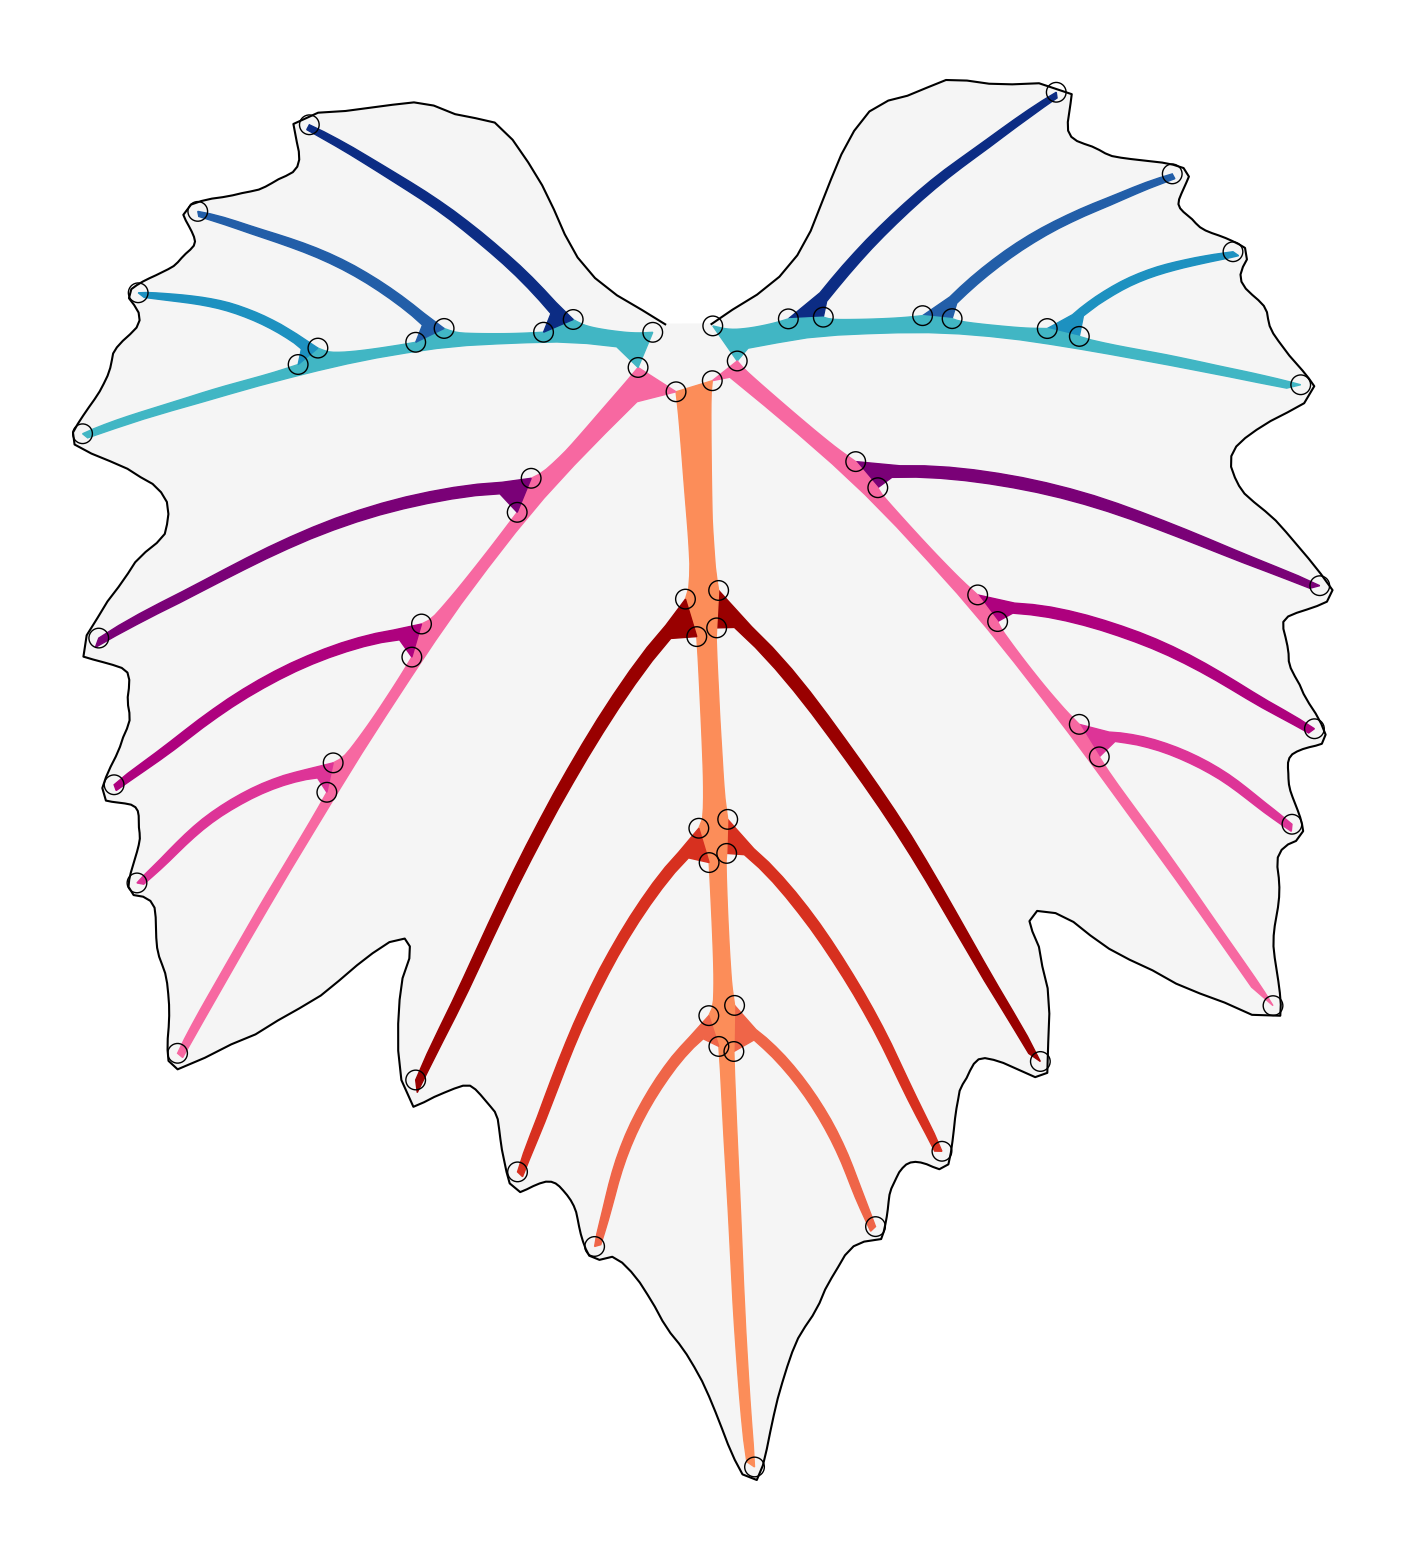

In [ ]:
#################################
# plot the mean Procrustes leaf #
#################################

plt.figure(figsize=(20,20))

# blade outline
plt.plot(gpa_mean[num_vein_coords:,0],
         gpa_mean[num_vein_coords:,1], c="k")

# blade fill
plt.fill(gpa_mean[num_vein_coords:,0],
         gpa_mean[num_vein_coords:,1], c="whitesmoke")


plt.scatter(gpa_mean[vein_indices,0],
         gpa_mean[vein_indices,1],
           s=200, edgecolor="k", zorder=5, facecolor="none")

plt.fill(gpa_mean[lp1_indices,0],
         gpa_mean[lp1_indices,1], c=p1_col)

plt.fill(gpa_mean[lp2_indices,0],
         gpa_mean[lp2_indices,1], c=p2_col)

plt.fill(gpa_mean[lp3_indices,0],
         gpa_mean[lp3_indices,1], c=p3_col)

plt.fill(gpa_mean[lprox_indices,0],
         gpa_mean[lprox_indices,1], c=prox_col)

plt.fill(gpa_mean[ld1_indices,0],
         gpa_mean[ld1_indices,1], c=d1_col)

plt.fill(gpa_mean[ld2_indices,0],
         gpa_mean[ld2_indices,1], c=d2_col)

plt.fill(gpa_mean[ld3_indices,0],
         gpa_mean[ld3_indices,1], c=d3_col)

plt.fill(gpa_mean[ldist_indices,0],
         gpa_mean[ldist_indices,1], c=dist_col)

plt.fill(gpa_mean[lm1_indices,0],
         gpa_mean[lm1_indices,1], c=m1_col)

plt.fill(gpa_mean[lm2_indices,0],
         gpa_mean[lm2_indices,1], c=m2_col)

plt.fill(gpa_mean[lm3_indices,0],
         gpa_mean[lm3_indices,1], c=m3_col)

plt.fill(gpa_mean[mid_indices,0],
         gpa_mean[mid_indices,1], c=mid_col)

plt.fill(gpa_mean[rm3_indices,0],
         gpa_mean[rm3_indices,1], c=m3_col)

plt.fill(gpa_mean[rm2_indices,0],
         gpa_mean[rm2_indices,1], c=m2_col)

plt.fill(gpa_mean[rm1_indices,0],
         gpa_mean[rm1_indices,1], c=m1_col)

plt.fill(gpa_mean[rdist_indices,0],
         gpa_mean[rdist_indices,1], c=dist_col)

plt.fill(gpa_mean[rd3_indices,0],
         gpa_mean[rd3_indices,1], c=d3_col)

plt.fill(gpa_mean[rd2_indices,0],
         gpa_mean[rd2_indices,1], c=d2_col)

plt.fill(gpa_mean[rd1_indices,0],
         gpa_mean[rd1_indices,1], c=d1_col)

plt.fill(gpa_mean[rprox_indices,0],
         gpa_mean[rprox_indices,1], c=prox_col)

plt.fill(gpa_mean[rp3_indices,0],
         gpa_mean[rp3_indices,1], c=p3_col)

plt.fill(gpa_mean[rp2_indices,0],
         gpa_mean[rp2_indices,1], c=p2_col)

plt.fill(gpa_mean[rp1_indices,0],
         gpa_mean[rp1_indices,1], c=p1_col)

plt.gca().set_aspect("equal")
plt.axis("off")

plt.show()


### Labels for genotype and development / 遺伝型・発生ステージのラベル

Verbatim (cells 28–29, 75): node text from each leaf's metadata, recoded to `leaf1`–`leaf4` vs `mature`; plus the author's fixed genotype list (cell 73, order matches the retained leaves), recoded to vinifera / wild / rootstock / dissected. An assertion checks the list length against the retained leaf count.
メタデータのnode記述を発生ラベルへ、著者固定のリストを遺伝型ラベルへ変換（リスト長を保持葉数と照合）。

In [ ]:
for i in range(len(species_list)):
    
    name = species_list[i] # get curret name
    
    # replace name if 'AMPELOPSIS GLANDULOSA VAR BREVIPEDUNCULATA'
    # with "AMPELOPSIS GLANDULOSA"
    
    if name == 'AMPELOPSIS GLANDULOSA VAR BREVIPEDUNCULATA':
        name = "AMPELOPSIS GLANDULOSA"
        species_list[i] = name 

new_node_list = []

for i in range(len(node_list)):

    text = node_list[i] # get node description
    ind = text.index(",") # get position of comma
    node_text = text[:ind] # get node value
    
    new_node_list.append("node: " + node_text)

# recode labels as mature, leaf1, leaf2, leaf3, leaf4

devo_labels = []

for i in range(len(new_node_list)):
    
    if new_node_list[i][6:] == "mature":
        devo_labels.append("mature")
    elif int(new_node_list[i][6:]) <= 4:
        devo_labels.append("leaf" + str(int(new_node_list[i][-1])))
    elif int(new_node_list[i][6:]) > 4:
        devo_labels.append("mature")
        
devo_pal = { 
             "leaf1":"#F8485E",
             "leaf2":"#FF8F1C",
             "leaf3":"#FEDB00",
             "leaf4":"#97D700",
             "mature":"#1E22AA",
}


### Genotype labels / 遺伝型ラベル

Verbatim author cell 73: the fixed genotype list (vinifera / wild / rootstock / dissected), whose order corresponds to `index_list`. An assertion checks its length against the retained leaf count.
著者固定の遺伝型ラベル（順序は保持葉の順）。リスト長を保持葉数と照合します。

In [ ]:
# author cell 73, verbatim (order corresponds to index_list)
# recode labels as vinifera, wild, rootstock, dissected

geno_labels = ["vinifera",#'ALICANTE BOUSCHET'
 "vinifera",#'CABERNET SAUVIGNON'
 "vinifera",#'CHARDONNAY'
 "dissected",#'CHASSELAS CIOUTAT'
 "vinifera",#'CHASSELAS DORÉ'
 "vinifera",#'FLAME TOKAY'
 "vinifera",#'GEWÜRTZTRAMINER'
 "vinifera",#'PINOT NOIR'
 "vinifera",#'SYLVANER'
 "vinifera",#'SYRAH'
 "wild",#'VITIS ACERIFOLIA'
 "wild",#'VITIS AESTIVALIS'
 "wild",#'VITIS AMURENSIS'
 "wild",#'VITIS CINEREA'
 "wild",#'VITIS COIGNETIAE'
 "wild",#'VITIS LABRUSCA'
 "wild",#'VITIS PALMATA'
 "dissected",#'VITIS PIASEZKII'
 "wild",#'VITIS RIPARIA'
 "wild",#'VITIS RUPESTRIS'
 "wild",#'VITIS THUNBERGII'
 "wild",#'VITIS VULPINA'
 "vinifera",#'WHITE RIESLING'
 "vinifera",#'ZINFANDEL'
 "wild",#'VITIS RUPESTRIS'
 "dissected",#'AMPELOPSIS ACONITIFOLIA'
 "wild",#'VITIS RUPESTRIS'
 "dissected",#'CHASSELAS CIOUTAT'
 "dissected",#'CHASSELAS CIOUTAT'
 "wild",#'VITIS VULPINA'
 "wild",#'VITIS THUNBERGII'
 "dissected",#'AMPELOPSIS GLANDULOSA'
 "dissected",#'AMPELOPSIS GLANDULOSA'
 "wild",#'VITIS VULPINA'
 "dissected",#'VITIS PIASEZKII'
 "dissected",#'AMPELOPSIS ACONITIFOLIA'
 "dissected",#'AMPELOPSIS GLANDULOSA'
 "wild",#'VITIS RIPARIA'
 "wild",#'VITIS RUPESTRIS'
 "dissected",#'AMPELOPSIS ACONITIFOLIA'
 "wild",#'VITIS CINEREA'
 "wild",#'VITIS CINEREA'
 "wild",#'VITIS CINEREA'
 "wild",#'VITIS CINEREA'
 "wild",#'VITIS RUPESTRIS'
 "wild",#'VITIS RUPESTRIS'
 "wild",#'VITIS RUPESTRIS'
 "wild",#'VITIS RUPESTRIS'
 "wild",#'VITIS RIPARIA'
 "wild",#'VITIS RIPARIA'
 "wild",#'VITIS RIPARIA'
 "wild",#'VITIS RIPARIA'
 "wild",#'VITIS LABRUSCA'
 "wild",#'VITIS LABRUSCA'
 "wild",#'VITIS LABRUSCA'
 "wild",#'VITIS LABRUSCA'
 "wild",#'VITIS ACERIFOLIA'
 "wild",#'VITIS ACERIFOLIA'
 "wild",#'VITIS ACERIFOLIA'
 "wild",#'VITIS ACERIFOLIA'
 "wild",#'VITIS AMURENSIS'
 "wild",#'VITIS AMURENSIS'
 "wild",#'VITIS AMURENSIS'
 "wild",#'VITIS AMURENSIS'
 "wild",#'VITIS VULPINA'
 "wild",#'VITIS VULPINA'
 "wild",#'VITIS VULPINA'
 "wild",#'VITIS VULPINA'
 "wild",#'VITIS AESTIVALIS'
 "wild",#'VITIS AESTIVALIS'
 "wild",#'VITIS AESTIVALIS'
 "wild",#'VITIS AESTIVALIS'
 "wild",#'VITIS COIGNETIAE'
 "wild",#'VITIS COIGNETIAE'
 "wild",#'VITIS COIGNETIAE'
 "wild",#'VITIS COIGNETIAE'
 "wild",#'VITIS PALMATA'
 "wild",#'VITIS PALMATA'
 "wild",#'VITIS PALMATA'
 "wild",#'VITIS PALMATA'
 "wild",#'VITIS ROMANETII'
 "wild",#'VITIS DOANIANA'
 "wild",#'VITIS ROMANETII'
 "wild",#'VITIS DOANIANA'
 "rootstock",#'5C'
 "rootstock",#'5C'
 "rootstock",#'DOG RIDGE'
 "rootstock",#'DOG RIDGE'
 "vinifera",#'CORVINA VERONSE'
 "vinifera",#'CORVINA VERONSE'
 "rootstock",#'AXR1'
 "rootstock",#'AXR1'
 "wild",#'VITIS ACERIFOLIA'
 "rootstock",#'O39-16'
 "rootstock",#'O39-16'
 "vinifera",#'CINSAULT'
 "vinifera",#'CINSAULT'
 "rootstock",#'GRN3'
 "vinifera",#'MERLOT'
 "vinifera",#'MALVASIA BIANCA'
 "rootstock",#'1613C'
 "vinifera",#'TREBBIANO'
 "vinifera",#'SYLVANER'
 "vinifera",#'BONARDA'
 "vinifera",#'BONARDA'
 "rootstock",#'RS-9'
 "rootstock",#'RS-9'
 "vinifera",#'CABERNET FRANC'
 "vinifera",#'VALDEPENAS'
 "vinifera",#'VALDEPENAS'
 "vinifera",#'VESPOLINA'
 "vinifera",#'FOLLE BLANCE'
 "vinifera",#'FOLLE BLANCE'
 "vinifera",#'PETIT VERDOT'
 "vinifera",#'PETIT VERDOT'
 "rootstock",#'DOG RIDGE'
 "rootstock",#'RAMSEY'
 "rootstock",#'RAMSEY'
 "vinifera",#'PARELLADA'
 "vinifera",#'PARELLADA'
 "rootstock",#'44-53M'
 "rootstock",#'44-53M'
 "rootstock",#'1103P'
 "vinifera",#'MUSCAT OTTONEL'
 "vinifera",#'MUSCAT OTTONEL'
 "vinifera",#'SIEGERREBE'
 "rootstock",#'5C'
 "rootstock",#'5C'
 "rootstock",#'5BB'
 "rootstock",#'5BB'
 "vinifera",#'TANNAT'
 "vinifera",#'ALICANTE BOUSCHET'
 "rootstock",#'8B'
 "rootstock",#'8B'
 "vinifera",#'EMERALD RIESLING'
 "wild",#'VITIS ARIZONICA'
 "wild",#'VITIS ARIZONICA'
 "rootstock",#'DOG RIDGE'
 "vinifera"#'BURGER'
]

assert len(geno_labels) == len(index_list), (len(geno_labels), len(index_list))
print('geno labels:', len(geno_labels), Counter(geno_labels))


geno labels: 139 Counter({'wild': 65, 'vinifera': 38, 'rootstock': 25, 'dissected': 11})


### Procrustes alignment to the GPA mean / GPA平均への整位

Verbatim (cell 55): superimpose every shape on the GPA mean.
全ての形状をGPA平均に整位します。

In [ ]:
# an array to store procrustes aligned shapes
proc_arr = np.zeros((np.shape(shape_arr)[0],
                     np.shape(shape_arr)[1],
                     np.shape(shape_arr)[2]
                    ))
# for each leaf
for i in range(np.shape(shape_arr)[0]):

    # calculate superimposed shape to gpa_mean
    s1, s2, distance = procrustes(gpa_mean, shape_arr[i,:,:]) 
    
    # append procrustes shape to array
    proc_arr[i,:,:] = s2


## PCA morphospace / 主成分分析モルフォスペース

Verbatim (cells 71–72): flatten aligned shapes to `n × 3344`, fit a 2-PC PCA, and project the data. PC axes are orthogonal genetic/developmental axes of the paper's morphospace.
整位した形状をフラット化し2主成分のPCAを適用、データを射影します。

[0.46878774 0.10646871]
[0.46878774 0.57525645]


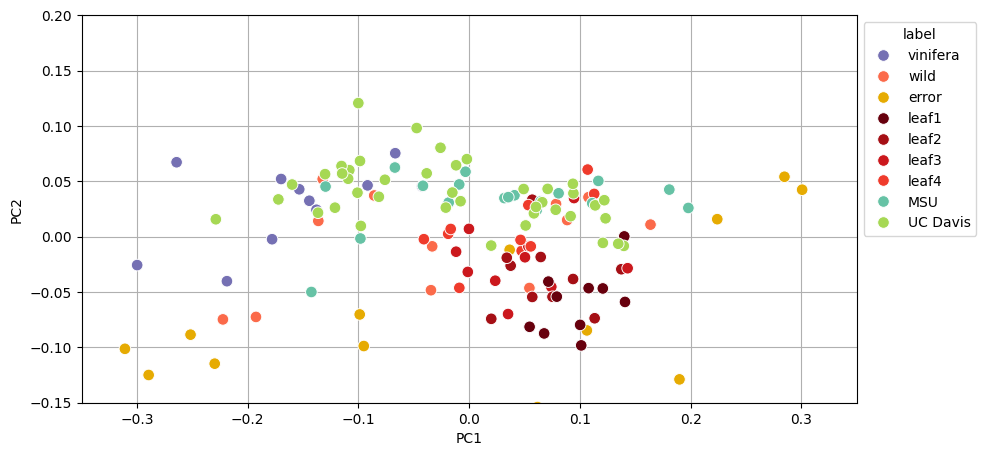

In [ ]:
# ADAPTATION: author cell 23 defines leaf_labels during its outlier-plot loop; that plot is
# omitted here, so the label list is built directly (same definition as author cell 23).
leaf_labels = [label_list[index_list[i]] for i in range(np.shape(shape_arr)[0])]
######
PC_NUMBER = 2
#######

# use the reshape function to flatten proc_arr to 2D
reshaped_arr = proc_arr.reshape(np.shape(proc_arr)[0], 
                                      np.shape(proc_arr)[1]*2) 

pca = PCA(n_components=PC_NUMBER) 
PCs = pca.fit_transform(reshaped_arr) # fit a PCA

print(pca.explained_variance_ratio_) # print out explained variance for each PC
print(pca.explained_variance_ratio_.cumsum())

# create pca df to visualize results in seaborn
pca_df = pd.DataFrame({
    "PC1":PCs[:,0],
    "PC2":PCs[:,1],
    "label":leaf_labels})

# create color palette for seaborn plot for labels
label_pal = {"vinifera":"#7570b3", 
             "wild":"#fb6a4a",
             "error":"#e6ab02",
             "MSU":"#66c2a5",
             "UC Davis":"#a6d854",
             "leaf1":"#67000d",
             "leaf2":"#a50f15",
             "leaf3":"#cb181d",
             "leaf4":"#ef3b2c",
             "rootstock":"green",
             "dissected":"gold"
            }

xlim1 = -0.35
xlim2 = 0.35
ylim1 = -0.15
ylim2 = 0.20

plt.figure(figsize=(10,10))
ax=sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", palette=label_pal, zorder=2, s=70)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xlim(xlim1,xlim2)
plt.ylim(ylim1,ylim2)
plt.grid()
plt.gca().set_aspect("equal")
plt.show()


### Eigenleaves (PC1–PC9, ±2σ) / 固有葉

Verbatim (cells 67–69): fit a 9-PC PCA, reconstruct shapes at −2…+2σ of each PC, and draw them colored by ln(vein/blade) — the paper's Fig. 4B eigenleaf panel. `cm.get_cmap` → `matplotlib.colormaps['plasma']` (removed API).
9主成分でPCAを再構築し、各PCの±2σで形状を逆変換した「固有葉」を描画（論文Fig.4B相当）。

[0.46878774 0.10646871 0.09085558 0.07667529 0.04799044 0.03296898
 0.02245957 0.02116436 0.01341635]
[0.46878774 0.57525645 0.66611203 0.74278732 0.79077775 0.82374674
 0.8462063  0.86737066 0.88078701]
0


5


10


15


20


25


30


35


40


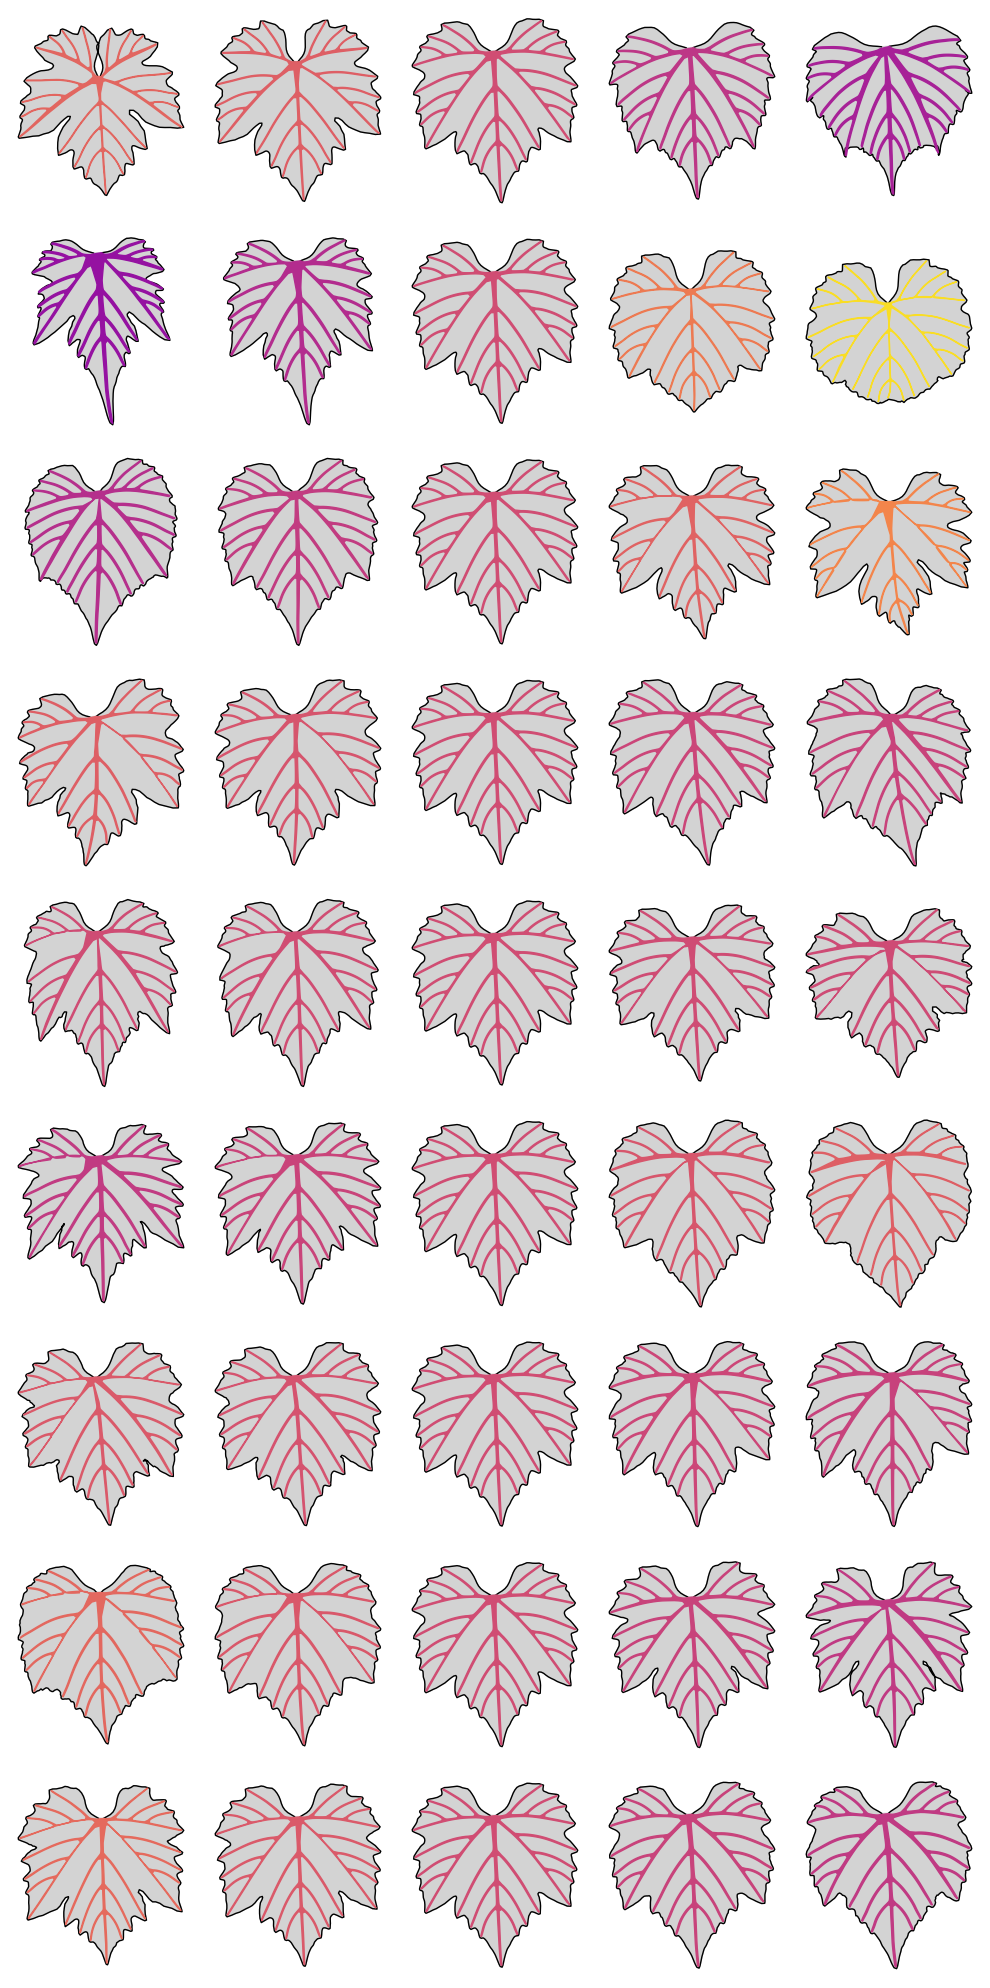

In [ ]:
######
PC_NUMBER = 9
#######

# use the reshape function to flatten proc_arr to 2D
reshaped_arr = proc_arr.reshape(np.shape(proc_arr)[0], 
                                      np.shape(proc_arr)[1]*2) 

pca = PCA(n_components=PC_NUMBER) 
PCs = pca.fit_transform(reshaped_arr) # fit a PCA

print(pca.explained_variance_ratio_) # print out explained variance for each PC
print(pca.explained_variance_ratio_.cumsum())

num_PCs = 9
st_devs = [-2,-1,0,1,2]

PCs_eigenleaves = np.zeros((45,9))

counter=0

for i in range(num_PCs):
    curr_PC = PCs[:,i]
    std_curr_PC = np.std(curr_PC)
    for j in st_devs:
        PC_std_val = std_curr_PC*j
        PCs_eigenleaves[counter,i] = PC_std_val
        counter+=1
        
PCs_eigenleaves

# Visualize random genotype leaves

plt.figure(figsize=(10,20))

cmap = matplotlib.colormaps['plasma'] # set the color map
counter = 1

for i in range(45):
    
    if i%5==0:
        print(i)

    inv_leaf = pca.inverse_transform(PCs_eigenleaves[i,:])
    inv_leaf = np.reshape(inv_leaf, (1672,2))

    inv_leaf_veinX = inv_leaf[0:num_vein_coords,0]
    inv_leaf_veinY = inv_leaf[0:num_vein_coords,1]
    inv_leaf_bladeX = inv_leaf[num_vein_coords:,0]
    inv_leaf_bladeY = inv_leaf[num_vein_coords:,1]
    
    vein_area = PolyArea(inv_leaf_veinX,inv_leaf_veinY)
    leaf_area = PolyArea(inv_leaf_bladeX,inv_leaf_bladeY)
    blade_area = leaf_area-vein_area
    vtb_ratio = np.log(vein_area/blade_area)
    vtb_min = -4
    norm_vtb = vtb_ratio/vtb_min
    hexcol = matplotlib.colors.rgb2hex(cmap(norm_vtb))

    plt.subplot(9,5,counter)
    plt.plot(inv_leaf_bladeX, inv_leaf_bladeY, c="k", lw=1)
    plt.fill(inv_leaf_bladeX, inv_leaf_bladeY, c="lightgray")
    plt.fill(inv_leaf_veinX, inv_leaf_veinY, c=hexcol, zorder=2)
    plt.gca().set_aspect("equal")
    plt.gca().set_facecolor("white")
    plt.axis("off")

    counter += 1
        
plt.tight_layout()
plt.show()


## LDA by genotype / 遺伝型の線形判別分析

Verbatim (cell 86): fit scikit-learn `LinearDiscriminantAnalysis` on the 3344 aligned coordinates, predict on the training data, and plot the confusion matrix (paper Fig. 5B). This is a resubstitution evaluation of the classifier on all leaves, not held-out validation.
3344座標を特徴量としてLDAを学習し、混同行列を表示（論文Fig.5B相当）。ホールドアウト検証ではなく全データでの再代入評価である点に注意。

Count of True values for genotype: 136
Count of False values for genotype: 3


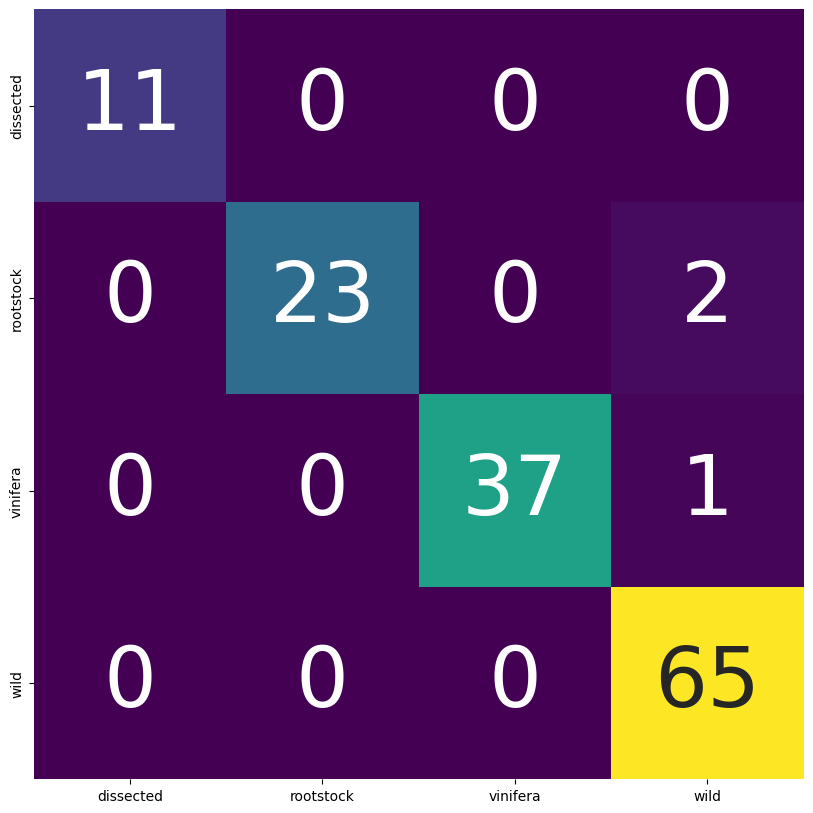

In [ ]:
# use the reshape function to flatten proc_arr to 2D
reshaped_arr = proc_arr.reshape(np.shape(proc_arr)[0], 
                                      np.shape(proc_arr)[1]*2) 

# create a df for LDA by genotype
geno_df = pd.DataFrame(data=reshaped_arr[:,:])

# add the genotype labels
geno_df["geno"] = geno_labels

# create input and output variables
X = geno_df.iloc[:,0:3344]
y = geno_df["geno"]

# fit the LDA model
geno_model = LinearDiscriminantAnalysis()
geno_model.fit(X,y)

# retrieve LDA scalings and coefficients
geno_scalings = geno_model.scalings_
geno_coefs = geno_model.coef_

# perform prediction
geno_prediction= geno_model.predict(X)
comparison_result = [X == y for X, y in zip(y, geno_prediction)]

count_true_pl = comparison_result.count(True)
count_false_pl = comparison_result.count(False)
print("Count of True values for genotype:", count_true_pl)
print("Count of False values for genotype:", count_false_pl)

# Create confusion matrix
true_geno_values = geno_labels
predicted_geno_values = geno_prediction

cm_geno = confusion_matrix(true_geno_values, predicted_geno_values)

classes = ["dissected","rootstock","vinifera","wild"]

plt.figure(figsize=(10,10))
sns.heatmap(cm_geno, annot=True, annot_kws={"fontsize":60}, fmt="d", cmap="viridis", square=True, cbar=False,xticklabels=classes,yticklabels=classes)
plt.show()


## LDA by developmental stage / 発生ステージの線形判別分析

Verbatim (cell 96): same procedure with `leaf1`–`leaf4`/`mature` labels (paper Fig. 6B).
同様に発生ステージ（leaf1〜leaf4/mature）のLDAと混同行列（論文Fig.6B相当）。

Count of True values by node: 138
Count of False values by node: 1


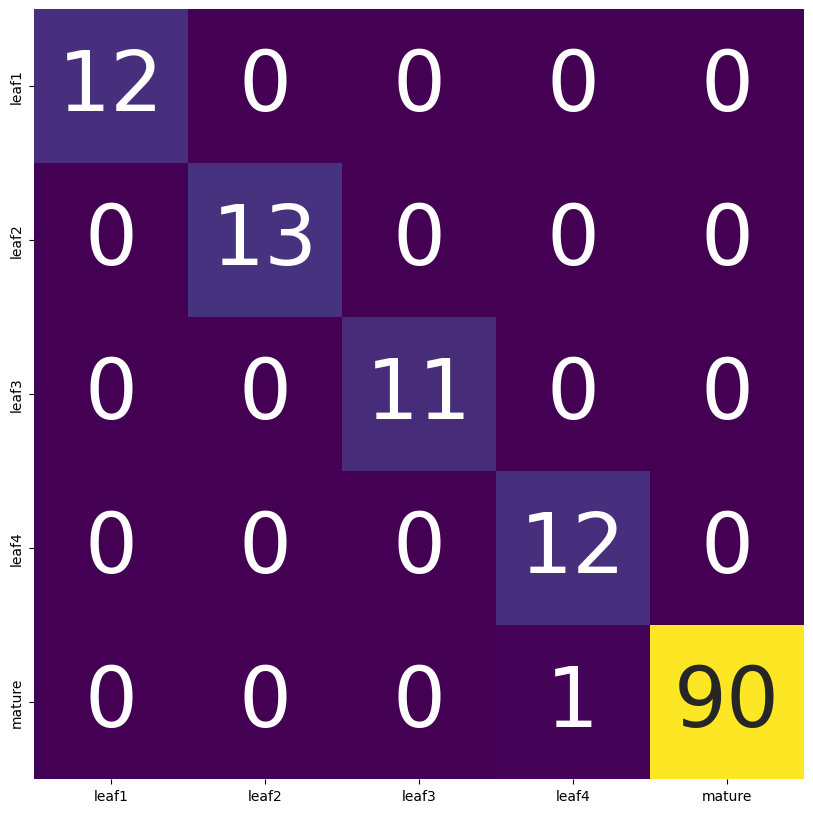

In [ ]:
# use the reshape function to flatten proc_arr to 2D
reshaped_arr = proc_arr.reshape(np.shape(proc_arr)[0], 
                                      np.shape(proc_arr)[1]*2) 

# create a df for LDA by genotype
devo_df = pd.DataFrame(data=reshaped_arr[:,:])

# add the development labels
devo_df["devo"] = devo_labels

# create input and output variables
X = devo_df.iloc[:,0:3344]
y = devo_df["devo"]

# fit the LDA model
devo_model = LinearDiscriminantAnalysis()
devo_model.fit(X,y)

# retrieve LDA scalings and coefficients
devo_scalings = devo_model.scalings_
devo_coefs = devo_model.coef_

# perform prediction
devo_prediction= devo_model.predict(X)
comparison_result = [X == y for X, y in zip(y, devo_prediction)]

count_true_pl = comparison_result.count(True)
count_false_pl = comparison_result.count(False)
print("Count of True values by node:", count_true_pl)
print("Count of False values by node:", count_false_pl)

# Create confusion matrix
true_devo_values = devo_labels
predicted_devo_values = devo_prediction

cm_devo = confusion_matrix(true_devo_values, predicted_devo_values)

classes = ["leaf1","leaf2","leaf3","leaf4","mature"]

plt.figure(figsize=(10,10))
sns.heatmap(cm_devo, annot=True,annot_kws={"fontsize":60}, fmt="d", cmap="viridis", square=True, cbar=False, xticklabels=classes,yticklabels=classes)
plt.show()


## Synthetic leaves from the 9-D convex hull / 9次元凸包からの合成葉

Verbatim (cells 107–110): uniformly sample the convex hull of the first 9 PCs (Delaunay simplices weighted by volume, Dirichlet barycentric coordinates; Stack Overflow snippet cited by the author), inverse-transform 500 samples, and draw them. **Adaptation:** `np.random.seed(0)` added for reproducibility (the author's draw is unseeded) and `np.math.factorial` → `math.factorial`.
最初の9主成分の凸包から一様に500点をサンプリングし、逆変換で「合成葉」を生成・描画（論文Fig.7相当）。乱数シード0を固定（著者版は未固定）。

0


50


100


150


200


250


300


350


400


450


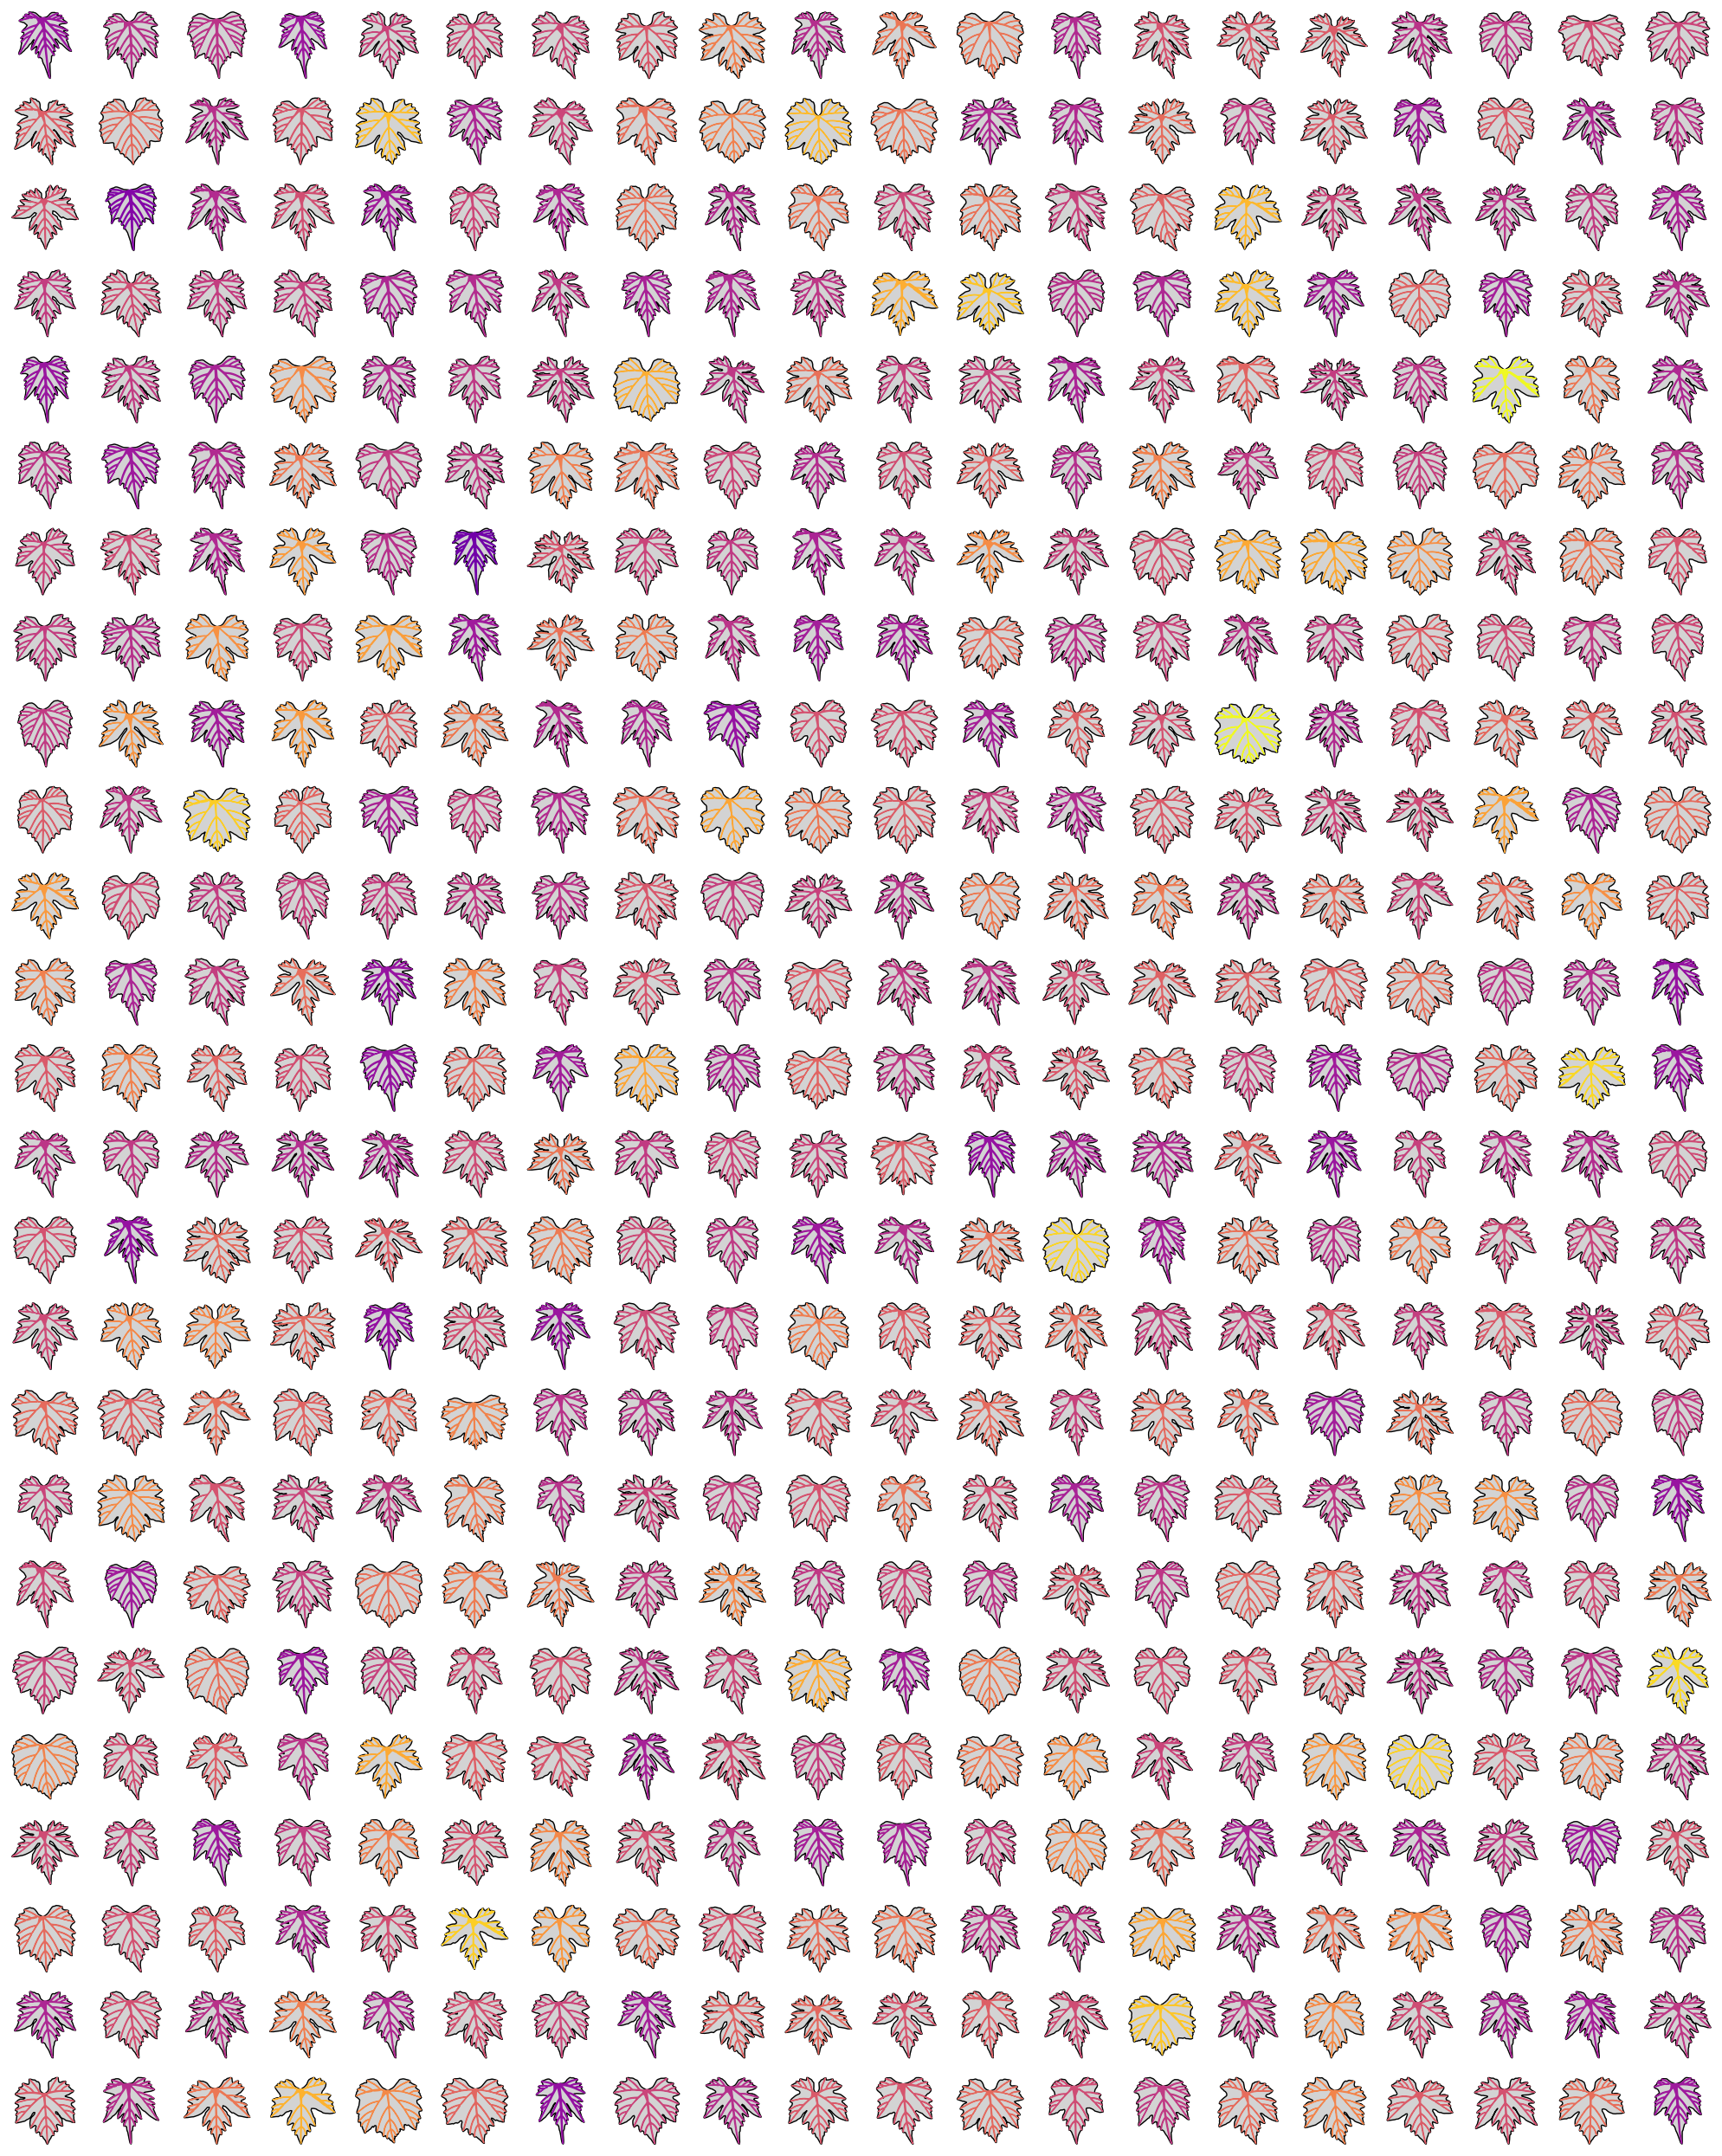

In [ ]:
np.random.seed(0)  # ADAPTATION: fixed seed; author draw was unseeded
# From: https://stackoverflow.com/questions/59073952/how-to-get-uniformly-distributed-points-in-convex-hull
# Accessed 11 February 2024

def dist_in_hull(points, n):
    dims = points.shape[-1]
    hull = points[ConvexHull(points).vertices]
    deln = hull[Delaunay(hull).simplices]

    vols = np.abs(det(deln[:, :dims, :] - deln[:, dims:, :])) / math.factorial(dims)    
    sample = np.random.choice(len(vols), size = n, p = vols / vols.sum())

    return np.einsum('ijk, ij -> ik', deln[sample], dirichlet.rvs([1]*(dims + 1), size = n))

######
PC_NUMBER = 9
#######

# use the reshape function to flatten proc_arr to 2D
reshaped_arr = proc_arr.reshape(np.shape(proc_arr)[0], 
                                      np.shape(proc_arr)[1]*2) 

pca = PCA(n_components=PC_NUMBER) 
PCs = pca.fit_transform(reshaped_arr) # fit a PCA

random_leaves = dist_in_hull(PCs,500)

# Visualize random genotype leaves


plt.figure(figsize=(20,25))

cmap = matplotlib.colormaps['plasma'] # set the color map
counter = 1
prob_cutoff = 0.95

for i in range(500):
    
    if i%50==0:
        print(i)

    inv_leaf = pca.inverse_transform(random_leaves[i,:])
    inv_leaf = np.reshape(inv_leaf, (1672,2))

    inv_leaf_veinX = inv_leaf[0:num_vein_coords,0]
    inv_leaf_veinY = inv_leaf[0:num_vein_coords,1]
    inv_leaf_bladeX = inv_leaf[num_vein_coords:,0]
    inv_leaf_bladeY = inv_leaf[num_vein_coords:,1]
    
    vein_area = PolyArea(inv_leaf_veinX,inv_leaf_veinY)
    leaf_area = PolyArea(inv_leaf_bladeX,inv_leaf_bladeY)
    blade_area = leaf_area-vein_area
    vtb_ratio = np.log(vein_area/blade_area)
    vtb_min = -4
    norm_vtb = vtb_ratio/vtb_min
    hexcol = matplotlib.colors.rgb2hex(cmap(norm_vtb))

    plt.subplot(25,20,counter)
    plt.plot(inv_leaf_bladeX, inv_leaf_bladeY, c="k", lw=1)
    plt.fill(inv_leaf_bladeX, inv_leaf_bladeY, c="lightgray")
    plt.fill(inv_leaf_veinX, inv_leaf_veinY, c=hexcol, zorder=2)
    plt.gca().set_aspect("equal")
    plt.gca().set_facecolor("white")
    plt.axis("off")

    counter += 1
        
plt.tight_layout()
plt.show()


## Results summary / 結果のまとめ

Small quantitative table of this run (counts, variance explained, resubstitution accuracy) and a CSV export under `/content`. These are observed from the actual execution above, not copied from the paper.
実行結果の要約表（件数・累積寄与率・再代入正解率）とCSV出力。

In [ ]:
rows = [
    ("leaves_total", len(leaf_list)),
    ("leaves_used", len(index_list)),
    ("pseudo_landmarks_per_leaf", num_pseuds),
    ("PC1_var_ratio", float(pca.explained_variance_ratio_[0])),
    ("PC2_var_ratio", float(pca.explained_variance_ratio_[1])),
    ("geno_LDA_resub_accuracy", float((np.array(geno_labels) == geno_prediction).mean())),
    ("devo_LDA_resub_accuracy", float((np.array(devo_labels) == devo_prediction).mean())),
    ("synthetic_leaves", int(random_leaves.shape[0])),
]
summary_df = pd.DataFrame(rows, columns=["metric", "value"])
display(summary_df)
summary_df.to_csv('/content/synthetic_leaves_summary.csv', index=False)
print('saved /content/synthetic_leaves_summary.csv')


,metric,value
0,leaves_total,152.000000
1,leaves_used,139.000000
2,pseudo_landmarks_per_leaf,1672.000000
3,PC1_var_ratio,0.468788
4,PC2_var_ratio,0.106469
5,geno_LDA_resub_accuracy,0.978417
6,devo_LDA_resub_accuracy,0.992806
7,synthetic_leaves,500.000000


saved /content/synthetic_leaves_summary.csv


## Interpretation and limitations / 解釈と限界

- The GPA mean leaf, eigenleaves, and both confusion matrices correspond to the paper's Figs. 1A, 4B, 5B and 6B, computed with the authors' own code and data on Colab.
- All LDA numbers are **resubstitution** (training-set) accuracies, exactly as in the author notebook; they are optimistic and not held-out validation.
- This notebook reproduces one subsection of the preprint: bootstrap reproducibility tests, the developmental polynomial models, prediction-shaded morphospace maps, and the original scans (Figshare 10.6084/m9.figshare.25325980) are out of scope.
- One-example scope note: the bundled trace dataset *is* the minimal unit of this subsection (126–139 shapes); no dataset-level claim of the paper is re-verified here.
- Provenance: data pinned to commit `9b7447c2a985e3d3aa2cfcedcbc98b81857d904d`, verified by git blob SHA-1; author code MIT-licensed (see repo `LICENSE`).

- GPA平均葉・固有葉・2つの混同行列は、著者自身のコードとデータをColab上で用いて、論文Fig.1A/4B/5B/6Bに対応します。
- LDAの数値は**再代入**精度（著者ノートブックと同じ）であり、楽観的な値です。
- ブートストラップ検証・発生モデル・予測着色マップ・原画像は対象外です。
- 出典：データはコミット `9b7447c…` に固定し git blob SHA-1 で検証。著者コードはMITライセンス。

**References:** Chitwood, D.H. (2024) bioRxiv 10.1101/2024.03.08.584086; code/data: github.com/DanChitwood/synthetic_leaves (MIT); original scans: figshare 25325980.